# EDIS 8100 · Week 11 · Co-Design Studio: Whose Dashboard Is This?

**Estimated time: about 30 minutes of code.** The rest of today is design dialogue, so this
notebook is deliberately light on machinery. Think of it as a sketchpad, not an analysis.

Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia

---

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. **Represent stakeholders as data**: read a set of persona cards that carry goals, fears, and
   decision rights, and explain why decision rights change what a metric is allowed to mean.
2. **Show that the measure picks the winner**: build four "top 500" lists from four defensible
   measures of the same enrolments, compare them against what chance alone would produce, and rule
   out the two boring explanations before believing the interesting one.
3. **Swap seats and critique**: read your own sketch through a second persona's eyes, and let the
   file answer back, because this file records what learners said they wanted before they started.
4. **Audit your own semester**: decide, artifact by artifact from weeks 1 through 11, who should
   have had a voice in the design and did not.

## How this notebook works (read this if you are new to code)

- Run the cells **top to bottom**. Click a cell and press **Shift + Enter**.
- **Nothing here can break your computer.** Everything runs in a temporary cloud machine on a
  published, anonymised, openly licensed file. If you break something, you break a copy.
- If a cell errors, the usual fix is to **re-run from the top**: `Runtime > Restart and run all`.
- Cells marked **✏️ Your turn** already contain working values. The notebook runs end to end even if
  you change nothing, so you can read first and edit second.
- You never need to write code from scratch here. Every edit is changing a word inside quotes or
  a number in a list.
- A few cells take five or ten seconds because they repeat a calculation hundreds of times to put
  an honest interval around it. That waiting is the point.

## ⚙️ Setup: where this data comes from

**Read this before you run anything.** You should never analyze data whose origin you cannot state.

| | |
|---|---|
| **Dataset** | Canvas Network Person-Course (1/2014 - 9/2015) De-Identified Open Dataset |
| **Who collected it** | Canvas Network, the open-course arm of the educational technology company Instructure, from its own platform logs and its own intake survey |
| **What one row is** | One person's activity in one course. 325,199 rows, 26 columns, 238 courses, January 2014 to September 2015 |
| **Licence** | **CC BY 4.0.** Free to use, share and adapt, including commercially, with attribution |
| **Where it lives** | Harvard Dataverse, `doi:10.7910/DVN/1XORAL`, deposited February 2016 |
| **How we get it** | The next code cell downloads one 3 MB file from `github.com/HakeoungLee/edis8100-datasets`. Nothing to install, no account, no password |

**Citation.** Canvas Network. (2016). *Canvas Network Person-Course (1/2014 - 9/2015)
De-Identified Open Dataset* [Data set]. Harvard Dataverse. https://doi.org/10.7910/DVN/1XORAL

**Who these people are, and what they were told.** Canvas Network hosted free, open online
courses that anyone could join. The people in this file signed up for a course on the open
internet, often out of curiosity, and their clicks were logged because logging is what a learning
platform does. Some of them also answered a short survey at registration. They were not recruited
into a study. Instructure anonymised the file, dropped or blurred the fields that could identify
someone, and published it so that people outside the company could learn something from it. That
is a real act of generosity by a company under no obligation to perform it, and it is also the
ordinary condition of learning analytics data: **the people in the file did not choose to be a
dataset.** Today of all weeks, hold on to that.

**What the anonymisation cost.** Three columns arrive empty or flattened. Country was replaced by
a single `*` on every row. Gender was withheld entirely. Age survives only as a bracket. Those are
not oversights, they are the price of publishing at all, and the first code cell will show you the
receipts.

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

pd.set_option('display.width', 150)
pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'font.size': 10})

# Okabe-Ito, a palette designed to stay distinguishable for the most common
# forms of colour vision deficiency. Every figure in this notebook uses it.
BLUE, ORANGE, GREEN, PINK = '#0072B2', '#E69F00', '#009E73', '#CC79A7'
SKY, VERM, YELLOW, GREY = '#56B4E9', '#D55E00', '#F0E442', '#999999'

URL = ('https://raw.githubusercontent.com/HakeoungLee/edis8100-datasets/'
       'main/canvas-network/person_course.csv.gz')

pc = None
try:
    pc = pd.read_csv(URL, low_memory=False)
except Exception as err:
    print('Could not download the data file.')
    print()
    print('The notebook was trying to read:')
    print('   ' + URL)
    print()
    print('This is almost always one of three things:')
    print('  1. no internet connection in this runtime;')
    print('  2. a firewall between you and github.com;')
    print('  3. the course dataset repository github.com/HakeoungLee/edis8100-datasets')
    print('     moved or was renamed.')
    print()
    print('Try Runtime > Restart and run all first. If it still fails, tell the instructor,')
    print('and paste this line so she knows which of the three it was:')
    print('   ' + type(err).__name__ + ': ' + str(err)[:160])

if pc is not None:
    print('Downloaded the Canvas Network person-course file.')
    print()
    print('   {:,} rows and {} columns'.format(pc.shape[0], pc.shape[1]))
    print('   {:,} distinct courses'.format(pc['course_id_DI'].nunique()))
    print('   {:,} distinct people'.format(pc['userid_DI'].nunique()))
    print('   courses starting {} through {}'.format(sorted(pc['course_start'].unique())[0],
                                                     sorted(pc['course_start'].unique())[-1]))
    print()
    print('One row is one person in one course. Ready.')

Downloaded the Canvas Network person-course file.

   325,199 rows and 26 columns
   238 distinct courses
   224,914 distinct people
   courses starting 2014 Q1 through 2015 Q3

One row is one person in one course. Ready.


## 1. 🧹 The mess, before anything else

Synthetic data arrives clean because someone built it clean. This file arrived from a company's
production database by way of an anonymisation pipeline, and it shows.

We are going to look at the mess **first**, on purpose, because two of the decisions we make in the
next four minutes will change every number in the rest of the notebook. If we made them quietly you
would have no way to argue with them, and arguing with design decisions is the entire subject of
today's session.

Three things to look for:

1. **Columns that arrive empty.** Anonymisation removed some, and the platform never recorded others.
2. **Columns that are recorded for a minority of rows.** This is the big one. Most of the interesting
   measures exist for a quarter of the file or less, and *which* quarter is not random.
3. **A column that speaks two languages.** One survey question got two different sets of answer
   labels, and nothing in the file tells you they are the same question.

In [1]:
# Which columns carry no information at all?
print('Columns that hold exactly one value on all {:,} rows:'.format(len(pc)))
for col in pc.columns:
    vals = pc[col].dropna().unique()
    if len(vals) == 1:
        print('   {:<20} every row says {!r}'.format(col, vals[0]))
print()
print('`registered` is 1 everywhere because the file only contains registrations.')
print('`final_cc_cname_DI` (country) and `gender` were withheld to protect the people in the file.')
print('Read that as a design constraint, not a gap: any fairness question you might want to')
print('ask about gender or country cannot be asked here, by the deliberate choice of the')
print('people who published it. Week 3 asked those questions of a dataset that allowed them.')

Columns that hold exactly one value on all 325,199 rows:
   registered           every row says 1
   final_cc_cname_DI    every row says '*'
   gender               every row says '{}'

`registered` is 1 everywhere because the file only contains registrations.
`final_cc_cname_DI` (country) and `gender` were withheld to protect the people in the file.
Read that as a design constraint, not a gap: any fairness question you might want to
ask about gender or country cannot be asked here, by the deliberate choice of the
people who published it. Week 3 asked those questions of a dataset that allowed them.


                     rows recorded of 325,199
completed_%                  26661       8.2%
nforum_posts                 37091      11.4%
learner_type                 38371      11.8%
primary_reason               38371      11.8%
expected_hours_week          38371      11.8%
LoE_DI                       38371      11.8%
ncontent                     41312      12.7%
grade                        82002      25.2%
nevents                      86287      26.5%
last_event_DI                92173      28.3%
start_time_DI                99844      30.7%
ndays_act                   101234      31.1%

Everything else in the file is recorded on all 325,199 rows.


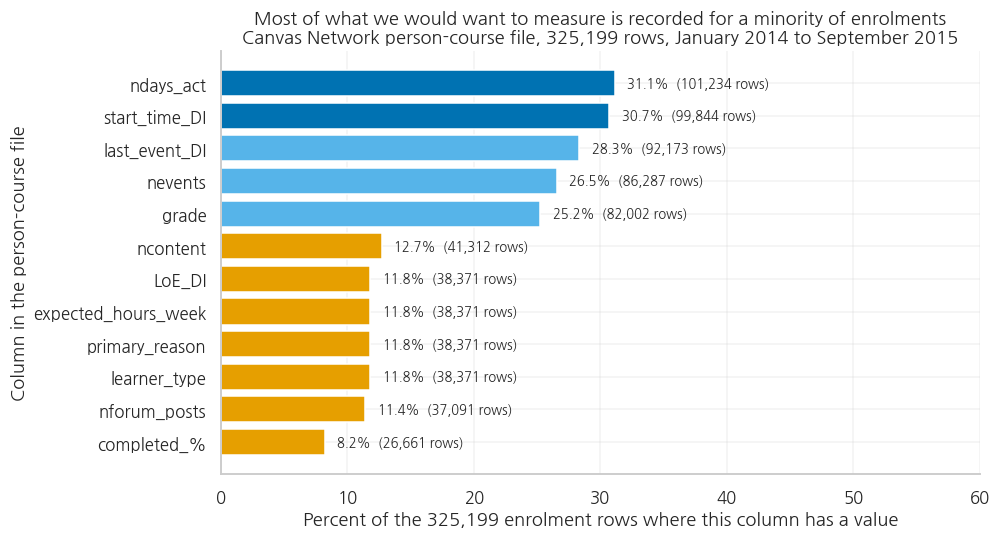

In [2]:
# How much of each column is actually recorded?
recorded = (pc.notna().sum() / len(pc) * 100).sort_values()
interesting = ['completed_%', 'nforum_posts', 'learner_type', 'primary_reason',
               'expected_hours_week', 'LoE_DI', 'ncontent', 'grade', 'nevents',
               'last_event_DI', 'start_time_DI', 'ndays_act']

tbl = pd.DataFrame({
    'rows recorded': pc[interesting].notna().sum(),
    'of 325,199': ['{:.1f}%'.format(recorded[c]) for c in interesting],
})
print(tbl.to_string())
print()
print('Everything else in the file is recorded on all {:,} rows.'.format(len(pc)))

fig, ax = plt.subplots(figsize=(9.2, 5.0))
share = pc[interesting].notna().mean() * 100
colors = [ORANGE if v < 15 else (SKY if v < 30 else BLUE) for v in share]
bars = ax.barh(interesting, share, color=colors, edgecolor='white')
for bar, v, n in zip(bars, share, pc[interesting].notna().sum()):
    ax.text(v + 1, bar.get_y() + bar.get_height() / 2,
            '{:.1f}%  ({:,} rows)'.format(v, n), va='center', fontsize=8.5)
ax.set_xlim(0, 60)
ax.set_xlabel('Percent of the 325,199 enrolment rows where this column has a value')
ax.set_ylabel('Column in the person-course file')
ax.set_title('Most of what we would want to measure is recorded for a minority of enrolments\n'
             'Canvas Network person-course file, 325,199 rows, January 2014 to September 2015')
plt.tight_layout()
plt.show()

**Interpretation prompt.** Before you explain any of this by something about the learners, work
down the list the way this course has worked down it since week 1.

1. **The instrument.** `nevents` is a count of recorded page views. A blank is not "this person did
   nothing", it is "this platform wrote nothing down for this person in this course". `grade` exists
   only for courses that had enough scored activities to compute one, which is a fact about the
   *course*, not the learner. `ncontent` requires the course to be built out of modules.
2. **The setting.** These are free, open courses on the public internet. Signing up costs nothing
   and carries no obligation, so a registration here is not the same act as a registration in
   EDIS 8100.
3. **The circumstances.** The file records nothing about the lives these people were living while
   the log was being written.

Now say out loud which of the three you think explains the 12.7 percent on `ncontent`, and notice
that you had to get all the way to number three before anything about a person came up.

### The column that speaks two languages

At registration, Canvas Network asked people what kind of participant they expected to be. The
answers live in `learner_type`. Print them and something is obviously wrong.

In [3]:
print(pc['learner_type'].value_counts(dropna=False).to_string())
print()
print('`Active` and `Active participant` are almost certainly the same answer with two different')
print('label wordings, and the same for `Passive`. Before we merge them we should check whether')
print('any single course ever used both, because if one did, they are more likely to be two')
print('genuinely different options.')
print()

real = pc[pc['learner_type'].notna() & (pc['learner_type'] != 'Missing')]
short_lbl, long_lbl = {'Active', 'Passive'}, {'Active participant', 'Passive participant'}
by_course = real.groupby('course_id_DI')['learner_type'].apply(
    lambda s: (len(set(s) & short_lbl) > 0, len(set(s) & long_lbl) > 0))
n_short = sum(1 for a, b in by_course if a and not b)
n_long = sum(1 for a, b in by_course if b and not a)
n_both = sum(1 for a, b in by_course if a and b)
print('Courses using the short labels only :', n_short)
print('Courses using the long  labels only :', n_long)
print('Courses using BOTH sets of labels   :', n_both)

learner_type
NaN                    286828
Active                  11782
Passive                 10253
Active participant       4387
Passive participant      3329
Missing                  3261
Drop-in                  2820
Observer                 2539

`Active` and `Active participant` are almost certainly the same answer with two different
label wordings, and the same for `Passive`. Before we merge them we should check whether
any single course ever used both, because if one did, they are more likely to be two
genuinely different options.

Courses using the short labels only : 112
Courses using the long  labels only : 33
Courses using BOTH sets of labels   : 0


**The decision, made in front of you.** Not one course of the 145 used both vocabularies. That is
what you would see if the survey wording changed once and every course inherited whichever version
was live when it launched. So we merge: `Active` becomes `Active participant`, `Passive` becomes
`Passive participant`.

**What the decision costs.** We cannot verify the merge. No course ran both wordings, so there is
no overlap anywhere in the file where the two labels describe the same people and we could check
that they behave alike. We are assuming it on the strength of the wording and the clean
course-level split, and if we are wrong we have just pooled two different questions. The honest
form of this decision is not to hide it but to write it down, which is what this paragraph is.

Two more small decisions, made the same way:

- **`Missing` is a value, not a blank.** 3,261 rows literally say `Missing` in `learner_type`. We
  drop them from the survey analysis and we say how many, rather than letting them quietly become
  a category.
- **We keep the survey rows as rows, not as people.** One person can enrol in several courses and
  answer the survey several times. We will report both counts every time it matters.

In [4]:
MERGE = {'Active': 'Active participant', 'Passive': 'Passive participant'}
PLAN_ORDER = ['Active participant', 'Passive participant', 'Drop-in', 'Observer']

survey = pc[pc['learner_type'].notna() & (pc['learner_type'] != 'Missing')].copy()
survey['plan'] = survey['learner_type'].replace(MERGE)

n_missing_label = int((pc['learner_type'] == 'Missing').sum())
print('Rows dropped because learner_type literally said "Missing":', n_missing_label)
print()
print('Declared plan at registration, after the merge:')
counts = survey['plan'].value_counts().reindex(PLAN_ORDER)
people = survey.groupby('plan')['userid_DI'].nunique().reindex(PLAN_ORDER)
print(pd.DataFrame({'enrolments': counts, 'distinct people': people}).to_string())
print()
print('Total: {:,} enrolments from {:,} distinct people.'.format(len(survey),
                                                                survey['userid_DI'].nunique()))
print('That is {:.1f} percent of the {:,} rows in the file.'.format(
    100 * len(survey) / len(pc), len(pc)))
print()
print('**Anyone who reasons from these answers is reasoning about respondents.**')
print('The other {:.1f} percent of the file never answered, and we have no way to know'.format(
    100 - 100 * len(survey) / len(pc)))
print('whether they would have answered the same way. This is the same warning as Week 5,')
print('where eleven annotated spans came from a single essay, and Week 9, where eight groups')
print('carried the whole finding. Range restriction is not a footnote. It is the finding.')

Rows dropped because learner_type literally said "Missing": 3261

Declared plan at registration, after the merge:
                     enrolments  distinct people
plan                                            
Active participant        16169            14364
Passive participant       13582            12327
Drop-in                    2820             2700
Observer                   2539             2442

Total: 35,110 enrolments from 30,336 distinct people.
That is 10.8 percent of the 325,199 rows in the file.

**Anyone who reasons from these answers is reasoning about respondents.**
The other 89.2 percent of the file never answered, and we have no way to know
whether they would have answered the same way. This is the same warning as Week 5,
where eleven annotated spans came from a single essay, and Week 9, where eight groups
carried the whole finding. Range restriction is not a footnote. It is the finding.


## 2. 🧑‍🤝‍🧑 Four people, written down as data

A persona is not a demographic sketch. For design purposes the useful parts of a person are:

- **Goals**: what they are actually trying to accomplish.
- **Fears**: what a bad version of this tool would do to them.
- **Decision rights**: what they are allowed to change once they see the number. This is the part
  most dashboards skip, and it is the part Bang and Vossoughi (2016) would say carries the power
  relations. A metric handed to someone with no authority to act on it is not information, it is
  pressure.
- **Grain**: whether they need the whole platform at once, one course, or one person.
- **Access reality**: what they would actually be allowed to see. Sometimes the honest answer is
  "nothing", and that is a design finding rather than an obstacle.
- **Their measure**: the one number each of them would reach for first. All four are in this file.
  That is what makes today's exercise possible, and it is the whole design of the session.

Four people stand around an open online course: the two people who made it, the company that hosts
it, the foundation that paid for it, and the person it is supposedly for. Watch which of the four
can see the least.

In [5]:
PERSONAS = {
    'teacher': dict(
        emoji='🧑‍🏫', name='Dana Okonkwo', measure='grade',
        role='Course team lead. Built and ran an open course with one colleague and no budget.',
        goals=[
            'Find out whether the course did anything for anyone, before deciding to run it again',
            'Work out which two modules to cut, because the course is too long and she knows it',
        ],
        fears=[
            'Being judged on a completion rate made mostly of people she never met',
            'A number that says the course failed when it did exactly what people came for',
            'Reading a low grade as a fact about a person rather than about her own assessment design',
        ],
        decision_rights=[
            'What the course contains and in what order',
            'What counts as complete, and where the certificate threshold sits',
            'What the welcome message says the course is for',
        ],
        cannot_change=['Who registers', 'What the platform logs', 'Whether anyone finishes'],
        grain='one course',
        access_reality='Sees her own course dashboard. Sees nothing about the same person in any other course.',
        question='Did this course do anything for anyone, and how would I know?'),
    'learner': dict(
        emoji='🎓', name='Malik Ferrer', measure='ncontent',
        role='Adult enrollee. Signed up on a Tuesday, works full time, answered the intake survey.',
        goals=[
            'Get to the two topics he actually signed up for',
            'Decide by the end of week two whether this is worth his evenings',
        ],
        fears=[
            'Being counted as somebody\'s "dropout" for doing exactly what he said he would do',
            'A completion number following him somewhere he cannot see it',
            'Being compared with people who wanted something different from the same course',
        ],
        decision_rights=[
            'Whether to open the course tonight',
            'Which modules to read and which to skip',
            'Whether to answer the intake survey, and how honestly',
        ],
        cannot_change=['Anything about the course', 'Anything about the platform',
                       'What is recorded about him'],
        grain='himself',
        access_reality=('Sees a progress bar if the course has one. Sees none of the rest, '
                        'and was never told this file would exist.'),
        question='Did I get what I came for, and is anything here even about that?'),
    'platform': dict(
        emoji='📈', name='Tobias Lindqvist', measure='nevents',
        role='Analytics lead at the company hosting the courses. Reports to leadership and to partners.',
        goals=[
            'Show partner institutions that the platform is being used',
            'Find which courses hold attention, so engineering time goes somewhere defensible',
        ],
        fears=[
            'A quarter where usage falls and he has to explain it',
            'A metric he cannot fit on one slide',
        ],
        decision_rights=[
            'What the dashboard shows, and to whom',
            'Which courses are promoted on the front page',
            'What the platform starts and stops logging next quarter',
        ],
        cannot_change=['What any individual course teaches'],
        grain='the whole platform',
        access_reality='Sees everything in this file, and a great deal more that was never published.',
        question='Is the platform being used, by whom, and can I put it on one slide?'),
    'funder': dict(
        emoji='🏛️', name='Ana Whitfield', measure='ndays_act',
        role='Programme officer at the foundation that paid for several of these courses to be built.',
        goals=[
            'Know whether the grant produced use that lasted longer than a week',
            'Decide what to fund next cycle, and defend it to a board in April',
        ],
        fears=[
            'Having paid for registrations that were one click and nothing after',
            'Being handed a number that a different measure would flatly contradict',
        ],
        decision_rights=[
            'Which proposals get funded next cycle',
            'What she requires grantees to report, and in what form',
        ],
        cannot_change=['The course', 'The platform', 'The people'],
        grain='a portfolio of courses',
        access_reality='Sees whatever the grantee chooses to report, which is usually a single number.',
        question='Did people keep coming back, and did we pay for that?'),
}

PERSONA_ORDER = ['teacher', 'learner', 'platform', 'funder']

def show_persona(key):
    p = PERSONAS[key]
    print('=' * 86)
    print('{}  {}  ({})'.format(p['emoji'], p['name'], key))
    print('   ' + p['role'])
    print('   Their question: "{}"'.format(p['question']))
    print('   Grain they think in: {}'.format(p['grain']))
    print('   Access reality: {}'.format(p['access_reality']))
    print('   The measure they reach for first: {}'.format(p['measure']))
    for label, items in [('GOALS', p['goals']), ('FEARS', p['fears']),
                         ('DECISION RIGHTS', p['decision_rights']),
                         ('CANNOT CHANGE', p['cannot_change'])]:
        print('   {}:'.format(label))
        for it in items:
            print('      - ' + it)

for k in PERSONA_ORDER:
    show_persona(k)
print('=' * 86)

🧑‍🏫  Dana Okonkwo  (teacher)
   Course team lead. Built and ran an open course with one colleague and no budget.
   Their question: "Did this course do anything for anyone, and how would I know?"
   Grain they think in: one course
   Access reality: Sees her own course dashboard. Sees nothing about the same person in any other course.
   The measure they reach for first: grade
   GOALS:
      - Find out whether the course did anything for anyone, before deciding to run it again
      - Work out which two modules to cut, because the course is too long and she knows it
   FEARS:
      - Being judged on a completion rate made mostly of people she never met
      - A number that says the course failed when it did exactly what people came for
      - Reading a low grade as a fact about a person rather than about her own assessment design
   DECISION RIGHTS:
      - What the course contains and in what order
      - What counts as complete, and where the certificate threshold sits
      - Wh

**Read before you scroll past.** Three of these four can change something. The fourth can change
only which tab he has open, and he is the one every row of this file is about.

Notice also that no persona is a data type. There is no `funder` column and no `course_team` column.
Prieto-Alvarez, Martinez-Maldonado, and Anderson (2018) would point out that the people most
affected by a learning analytics tool are frequently the people with no representation in the schema
at all, and here it is the learner who is represented most and consulted least.

One thing this file does unusually well, and it will matter in section 6: it records what the
learner said he wanted **before the course started**. Most learning analytics datasets record only
what people did. This one recorded, from 36,495 enrolments, why they came.

## 3. 📊 The metric menu

You cannot co-design in the abstract, so here is a real menu, computed from this file, one number
per enrolment.

**A decision you need to watch us make.** The four measures our personas care about are recorded on
different subsets of the file: `grade` on 25.2 percent of rows, `nevents` on 26.5, `ndays_act` on
31.1, `ncontent` on 12.7. If we compare four lists drawn from four different populations, any
disagreement between them could be nothing more than the file's silence.

So from here on we work on the **common population**: the enrolments where all four are recorded.
The cell below builds it and tells you exactly what that restriction costs.

Each metric carries three annotations that matter more than its formula:

- **direction**: is more of this better? For nearly all of these the honest answer is *contested*.
- **what it is often mistaken for**: the leap a tired reader makes at 4:45 on a Thursday.
- **who can act on it**: scored per persona, `0` cannot act, `1` can act only after a conversation,
  `2` can act directly.

In [6]:
FOUR = ['grade', 'nevents', 'ndays_act', 'ncontent']   # one per persona

core = pc[pc[FOUR].notna().all(axis=1)].copy()
core['passed_70'] = (core['grade'] >= 0.70).astype(int)
core['events_per_day'] = core['nevents'] / core['ndays_act']

METRIC_KEYS = ['grade', 'passed_70', 'nevents', 'events_per_day',
               'ndays_act', 'ncontent', 'explored']

print('Common population: enrolments with all four persona measures recorded')
print('   {:,} of {:,} rows kept  ({:.1f} percent)'.format(len(core), len(pc),
                                                           100 * len(core) / len(pc)))
print('   {:,} distinct people, {} of the {} courses'.format(
    core['userid_DI'].nunique(), core['course_id_DI'].nunique(), pc['course_id_DI'].nunique()))
print('   {:,} of these enrolments also answered the intake survey'.format(
    int(core['learner_type'].notna().sum() - (core['learner_type'] == 'Missing').sum())))
print()
print('WHAT THE RESTRICTION COSTS, said plainly:')
print('   We dropped {:,} rows, which is {:.1f} percent of the file.'.format(
    len(pc) - len(core), 100 * (1 - len(core) / len(pc))))
print('   The rows we kept are not a random sample. Median grade where a grade exists at all')
print('   is {:.2f} across the whole file and {:.2f} here, because a course that records all four'.format(
    pc['grade'].median(), core['grade'].median()))
print('   measures is a more built-out course than one that records none of them.')
print('   Everything after this point is a statement about {:,} enrolments in {} courses,'.format(
    len(core), core['course_id_DI'].nunique()))
print('   not about the {:,} in the file and certainly not about open online learning.'.format(len(pc)))

Common population: enrolments with all four persona measures recorded
   21,693 of 325,199 rows kept  (6.7 percent)
   19,924 distinct people, 156 of the 238 courses
   4,213 of these enrolments also answered the intake survey

WHAT THE RESTRICTION COSTS, said plainly:
   We dropped 303,506 rows, which is 93.3 percent of the file.
   The rows we kept are not a random sample. Median grade where a grade exists at all
   is 0.12 across the whole file and 0.37 here, because a course that records all four
   measures is a more built-out course than one that records none of them.
   Everything after this point is a statement about 21,693 enrolments in 156 courses,
   not about the 325,199 in the file and certainly not about open online learning.


In [7]:
# The catalog: what each metric is, and what it does to each persona.
# act scores: 0 = cannot act on it, 1 = can act after a conversation, 2 = can act directly.
CATALOG = pd.DataFrame([
    dict(metric='grade', label='Final grade recorded by the course', unit='0 to 1',
         direction='contested', mistaken_for='how much this person learned',
         act_teacher=2, act_learner=1, act_platform=1, act_funder=2, fears='teacher,learner'),
    dict(metric='passed_70', label='Reached a grade of 0.70 or more', unit='0 or 1',
         direction='contested', mistaken_for='completion, and then success',
         act_teacher=2, act_learner=1, act_platform=2, act_funder=2, fears='teacher,learner'),
    dict(metric='nevents', label='Recorded page views in the course', unit='page views',
         direction='contested', mistaken_for='effort',
         act_teacher=1, act_learner=0, act_platform=2, act_funder=1, fears='learner'),
    dict(metric='events_per_day', label='Recorded page views per active day', unit='views/day',
         direction='contested', mistaken_for='intensity, and then cramming',
         act_teacher=1, act_learner=1, act_platform=1, act_funder=0, fears='learner'),
    dict(metric='ndays_act', label='Distinct days with any recorded activity', unit='days',
         direction='contested', mistaken_for='commitment',
         act_teacher=1, act_learner=1, act_platform=2, act_funder=2, fears='learner'),
    dict(metric='ncontent', label='Percent of the course modules reached', unit='percent',
         direction='higher is better', mistaken_for='having understood the modules',
         act_teacher=2, act_learner=2, act_platform=1, act_funder=1, fears=''),
    dict(metric='explored', label='Platform flag: reached at least half the modules', unit='0 or 1',
         direction='contested', mistaken_for='seriousness',
         act_teacher=1, act_learner=0, act_platform=2, act_funder=1, fears='learner'),
]).set_index('metric').loc[METRIC_KEYS]

# Short forms, for figure axes where the full label will not fit.
CATALOG['short'] = ['final grade', 'reached 0.70', 'page views', 'views per day',
                    'active days', 'modules reached', 'explored flag']

print(CATALOG[['label', 'unit', 'direction', 'mistaken_for']].to_string())
print()
print('Notice what is NOT on this menu: not one metric is "lower is better".')
print('On a platform nobody was required to use, there is no measure where less of it is')
print('straightforwardly worse. Be suspicious of any dashboard here that flags a person for')
print('having too little of something.')
print()
print('Also not on the menu: forum posts. `nforum_posts` is recorded for {:,} of these {:,}'.format(
    int(core['nforum_posts'].notna().sum()), len(core)))
print('enrolments, so putting it beside the others would silently change the population again.')
print('A metric you cannot compare on equal terms is a metric that stays off the menu, and')
print('saying so out loud is the cheapest honesty available to a designer.')

                                                           label        unit         direction                   mistaken_for
metric                                                                                                                       
grade                         Final grade recorded by the course      0 to 1         contested   how much this person learned
passed_70                        Reached a grade of 0.70 or more      0 or 1         contested   completion, and then success
nevents                        Recorded page views in the course  page views         contested                         effort
events_per_day                Recorded page views per active day   views/day         contested   intensity, and then cramming
ndays_act               Distinct days with any recorded activity        days         contested                     commitment
ncontent                   Percent of the course modules reached     percent  higher is better  having understood the 

In [8]:
# Can each measure even produce a ranking? Ties at the top decide that, and two of these
# four cannot. This is a property of the measure, not of the people.
print('If a dashboard showed a "top 500", how many enrolments are tied at the cut-off?')
print()
for m in FOUR:
    s = core[m]
    cut = s.nlargest(500).min()
    tied = int((s == cut).sum())
    print('   {:<10} 500th largest value = {:<10} enrolments sitting at exactly that value: {:,}'
          .format(m, cut, tied))
print()
n_ceiling = int((core['ncontent'] == 100).sum())
n_perfect = int((core['grade'] == 1.0).sum())
print('{:,} of the {:,} enrolments here ({:.1f} percent) reached 100 percent of the modules,'.format(
    n_ceiling, len(core), 100 * n_ceiling / len(core)))
print('and {:,} scored a perfect 1.0. Any "top 500" on those two measures is a lottery among'.format(
    n_perfect))
print('thousands of tied people, decided by whatever order the database happened to return.')
print('Page views and active days have almost no ties and can genuinely rank.')
print()
print('Hold on to this. It means the learner\'s own measure is the one measure here that')
print('cannot make a leaderboard, which may be part of why nobody builds one on it.')

If a dashboard showed a "top 500", how many enrolments are tied at the cut-off?

   grade      500th largest value = 1.0        enrolments sitting at exactly that value: 1,370
   nevents    500th largest value = 9512.0     enrolments sitting at exactly that value: 1
   ndays_act  500th largest value = 38.0       enrolments sitting at exactly that value: 52
   ncontent   500th largest value = 100.0      enrolments sitting at exactly that value: 10,587

10,587 of the 21,693 enrolments here (48.8 percent) reached 100 percent of the modules,
and 1,370 scored a perfect 1.0. Any "top 500" on those two measures is a lottery among
thousands of tied people, decided by whatever order the database happened to return.
Page views and active days have almost no ties and can genuinely rank.

Hold on to this. It means the learner's own measure is the one measure here that
cannot make a leaderboard, which may be part of why nobody builds one on it.


**Interpretation prompt.** The ceiling on `ncontent` is not a nuisance to be transformed away. It is
a fact about what the measure is for.

Before you explain it by anything about learners, ask the two questions this course always asks
first. **What did the instrument do?** A percent-of-modules-reached measure is bounded above by 100
and a great many people reach the end of a short course. **What did the setting do?** These courses
are free and self-paced, and a module is "reached" by opening it.

Then answer this, in one sentence to your partner: a measure that saturates cannot rank, and a
measure that cannot rank cannot make a leaderboard. Which of the four people in section 2 benefits
from that, and which one loses?

## 4. ✏️ Your turn: pick a persona and pick your metrics

Change the three values in the next cell. **Working defaults are already filled in**, so if you run
it untouched everything downstream still works.

- `MY_PERSONA`: one of `'teacher'`, `'learner'`, `'platform'`, `'funder'`.
- `MY_METRICS`: two to four keys from `METRIC_KEYS` printed above. Fewer is braver.
- `FOCUS_COURSE` and `FOCUS_USER`: one enrolment to put on the individual panel. The default is a
  real row, chosen because it embarrasses every simple story you might want to tell.

Constraint that makes this a design exercise rather than a shopping trip: **four metrics maximum.**
Every metric you add costs the reader attention, and attention is the scarce resource in the room
where the dashboard gets used.

In [9]:
# ✏️ EDIT THESE FOUR LINES (or run as-is)
MY_PERSONA = 'teacher'
MY_METRICS = ['grade', 'passed_70', 'ndays_act', 'ncontent']
FOCUS_COURSE = 832960046
FOCUS_USER = 832985011

# --- validation, so a typo tells you instead of failing weirdly three cells later ---
assert MY_PERSONA in PERSONAS, 'MY_PERSONA must be one of {}'.format(list(PERSONAS))
assert 1 <= len(MY_METRICS) <= 4, 'Pick between 1 and 4 metrics.'
bad = [m for m in MY_METRICS if m not in METRIC_KEYS]
assert not bad, 'Unknown metric(s): {}. Choose from {}'.format(bad, METRIC_KEYS)
hit = core[(core['course_id_DI'] == FOCUS_COURSE) & (core['userid_DI'] == FOCUS_USER)]
assert len(hit) == 1, ('That course/user pair is not in the common population. '
                       'Keep the default, or pick a pair from core[["course_id_DI","userid_DI"]].')
FOCUS = hit.index[0]

p = PERSONAS[MY_PERSONA]
row = core.loc[FOCUS]
print('Designing for {} {} ({})'.format(p['emoji'], p['name'], MY_PERSONA))
print('Their question: "{}"'.format(p['question']))
print()
print('Focus enrolment: person {} in course {}'.format(FOCUS_USER, FOCUS_COURSE))
print('   discipline {}, course length {} days'.format(row['discipline'], row['course_length']))
print('   declared at registration: {!r}, reason: {!r}'.format(row['learner_type'],
                                                               row['primary_reason']))
print('   expected to spend: {!r}'.format(row['expected_hours_week']))
print('   grade {:.2f} | page views {:,.0f} | active days {:.0f} | modules reached {:.0f} percent'
      .format(row['grade'], row['nevents'], row['ndays_act'], row['ncontent']))
print()
print('Your metric set:')
print(CATALOG.loc[MY_METRICS, ['label', 'unit', 'direction']].to_string())

Designing for 🧑‍🏫 Dana Okonkwo (teacher)
Their question: "Did this course do anything for anyone, and how would I know?"

Focus enrolment: person 832985011 in course 832960046
   discipline Education, course length 16 days
   declared at registration: 'Active participant', reason: 'I enjoy learning about topics that interest me'
   expected to spend: 'Between 1 and 2 hours'
   grade 0.00 | page views 5,137 | active days 6 | modules reached 100 percent

Your metric set:
                                              label     unit         direction
metric                                                                        
grade            Final grade recorded by the course   0 to 1         contested
passed_70           Reached a grade of 0.70 or more   0 or 1         contested
ndays_act  Distinct days with any recorded activity     days         contested
ncontent      Percent of the course modules reached  percent  higher is better


### 📊 The sketch

Two panels, because almost every learning analytics view is secretly one of these two shapes:

- **Left, the population**: the distribution of your first metric across the common population, with
  the focus enrolment marked. This is the shape that answers "compared to whom".
- **Right, the person**: the focus enrolment's **percentile** on each metric you chose, shown twice.
  Once against everybody in the common population, and once against **only the other people in the
  same course**.

That second bar is the one to watch. Rows in this file nest inside courses, and courses grade wildly
differently. A grade of 0.5 means one thing in a course whose median grade is near zero and
something else entirely in a course whose median grade is a perfect 1.0, and both kinds of course
are in here. The cell below counts them. A percentile computed across all the courses at once
quietly averages over that difference, so where the two bars disagree sharply, the across-course
bar is telling you about the course rather than about the person.

One more warning, and it is the nastier one. A percentile bar reads as "longer is better" no matter
what it measures, and it **guarantees somebody is at the bottom** even in a population where
everyone is fine. A percentile can never say "all good here". Watch what that does to the persona
who fears being compared.

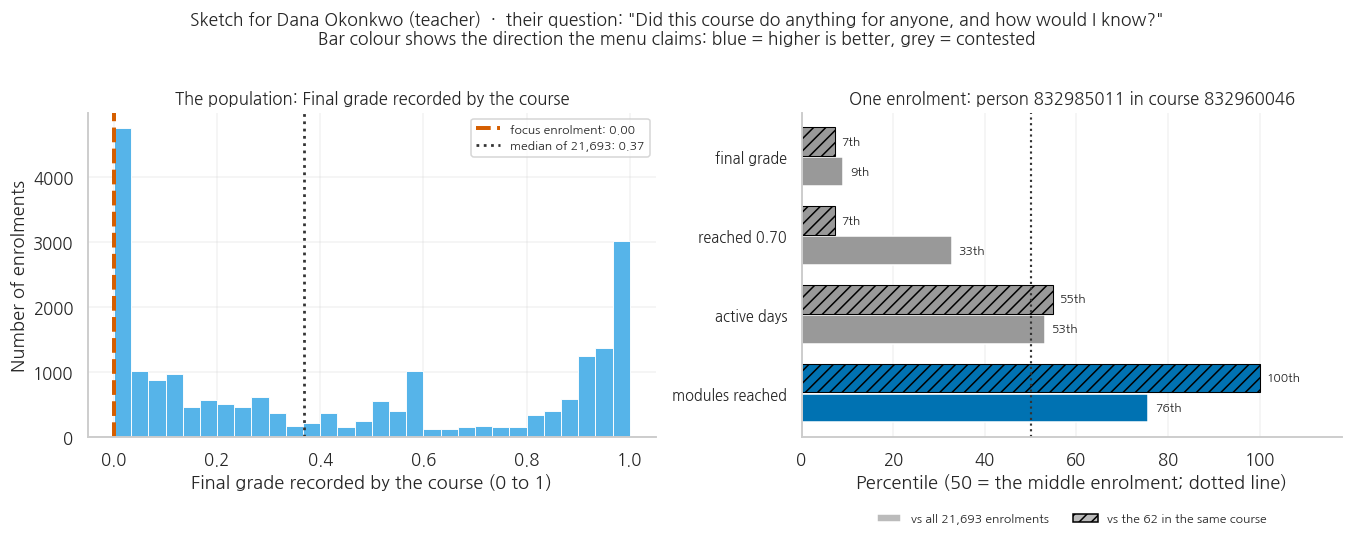

The default focus enrolment, in words:
   Registered saying "Active participant" and "I enjoy learning about topics that interest me".
   Read 100 percent of the modules and generated 5,137 page views in 6 days.
   That is the highest page-view count among all 436 registrations in that course,
   and they are the only one of the 64 with a modules-reached number who reached all of them.
   The course also recorded that they completed 75 percent of the required modules.
   Their final grade is 0.00. The median final grade among the 62 enrolments in that
   course with all four measures recorded is 1.00.

How differently do these courses grade? Of the 66 courses here with at least 30 such
enrolments, 17 have a median final grade at or below 0.10 and 7 have a median at or
above 0.95. That is the spread the across-course percentile bar is averaging over.


In [10]:
DIRECTION_COLOR = {'higher is better': BLUE, 'lower is better': ORANGE, 'contested': GREY}

pct_all = core[METRIC_KEYS].rank(pct=True) * 100
pct_course = core.groupby('course_id_DI')[METRIC_KEYS].rank(pct=True) * 100


def sketch_view(persona_key, metrics, focus_idx):
    '''Two-panel mock of what this persona would see.'''
    p = PERSONAS[persona_key]
    head = metrics[0]
    r = core.loc[focus_idx]
    same_course = core[core['course_id_DI'] == r['course_id_DI']]

    fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.2),
                             gridspec_kw={'width_ratios': [1.05, 1.0]})

    # ---- Panel 1: the population distribution of the headline metric
    ax = axes[0]
    vals = core[head]
    heavy = head in ('nevents', 'events_per_day')
    if heavy:
        bins = np.logspace(np.log10(max(vals.min(), 0.05)), np.log10(vals.max()), 40)
        ax.set_xscale('log')
    else:
        bins = 30
    ax.hist(vals, bins=bins, color=SKY, edgecolor='white', linewidth=0.6)
    ax.axvline(float(r[head]), color=VERM, linewidth=2.6, linestyle='--',
               label='focus enrolment: {:,.2f}'.format(r[head]))
    ax.axvline(float(vals.median()), color='#333333', linewidth=1.8, linestyle=':',
               label='median of {:,}: {:,.2f}'.format(len(core), vals.median()))
    ax.set_xlabel('{} ({}){}'.format(CATALOG.loc[head, 'label'], CATALOG.loc[head, 'unit'],
                                     ', log scale' if heavy else ''))
    ax.set_ylabel('Number of enrolments')
    ax.set_title('The population: {}'.format(CATALOG.loc[head, 'label']), fontsize=11)
    ax.legend(fontsize=8, loc='upper right' if not heavy else 'upper left')

    # ---- Panel 2: percentile profile, twice
    ax = axes[1]
    labels = [CATALOG.loc[m, 'short'] for m in metrics]
    y = np.arange(len(metrics))
    v_all = [float(pct_all.loc[focus_idx, m]) for m in metrics]
    v_crs = [float(pct_course.loc[focus_idx, m]) for m in metrics]
    cols = [DIRECTION_COLOR[CATALOG.loc[m, 'direction']] for m in metrics]
    ax.barh(y + 0.19, v_all, height=0.36, color=cols, edgecolor='white')
    ax.barh(y - 0.19, v_crs, height=0.36, color=cols, edgecolor='black', hatch='///',
            linewidth=0.7)
    for yy, v in zip(y + 0.19, v_all):
        ax.text(v + 1.5, yy, '{:.0f}th'.format(v), va='center', fontsize=8)
    for yy, v in zip(y - 0.19, v_crs):
        ax.text(v + 1.5, yy, '{:.0f}th'.format(v), va='center', fontsize=8)
    ax.axvline(50, color='#333333', linewidth=1.4, linestyle=':')
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9.5)
    ax.invert_yaxis()
    ax.set_xlim(0, 118)
    ax.set_xlabel('Percentile (50 = the middle enrolment; dotted line)')
    ax.set_ylabel('')
    ax.set_title('One enrolment: person {} in course {}'.format(r['userid_DI'], r['course_id_DI']),
                 fontsize=11)
    proxies = [plt.Rectangle((0, 0), 1, 1, facecolor='#BBBBBB', edgecolor='white'),
               plt.Rectangle((0, 0), 1, 1, facecolor='#BBBBBB', edgecolor='black', hatch='///')]
    ax.legend(proxies, ['vs all {:,} enrolments'.format(len(core)),
                        'vs the {} in the same course'.format(len(same_course))],
              fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2,
              frameon=False)
    ax.grid(axis='y', alpha=0)

    fig.subplots_adjust(bottom=0.24)
    fig.suptitle('Sketch for {} ({})  ·  their question: "{}"\n'
                 'Bar colour shows the direction the menu claims: blue = higher is better, '
                 'grey = contested'.format(p['name'], persona_key, p['question']),
                 fontsize=11.5, y=1.02)
    plt.tight_layout(rect=[0, 0.07, 1, 1])
    return fig


sketch_view(MY_PERSONA, MY_METRICS, FOCUS)
plt.show()

r = core.loc[FOCUS]
print('The default focus enrolment, in words:')
print('   Registered saying "{}" and "{}".'.format(r['learner_type'], r['primary_reason']))
crs_all = pc[pc['course_id_DI'] == r['course_id_DI']]
crs_core = core[core['course_id_DI'] == r['course_id_DI']]
print('   Read {:.0f} percent of the modules and generated {:,.0f} page views in {:.0f} days.'
      .format(r['ncontent'], r['nevents'], r['ndays_act']))
print('   That is the highest page-view count among all {:,} registrations in that course,'
      .format(len(crs_all)))
print('   and they are the only one of the {} with a modules-reached number who reached all of them.'
      .format(int(crs_all['ncontent'].notna().sum())))
print('   The course also recorded that they completed {:.0f} percent of the required modules.'
      .format(r['completed_%'] * 100))
print('   Their final grade is {:.2f}. The median final grade among the {} enrolments in that'
      .format(r['grade'], len(crs_core)))
print('   course with all four measures recorded is {:.2f}.'.format(crs_core['grade'].median()))
print()
spread = core.groupby('course_id_DI')['grade'].agg(['median', 'size'])
spread = spread[spread['size'] >= 30]
print('How differently do these courses grade? Of the {} courses here with at least 30 such'
      .format(len(spread)))
print('enrolments, {} have a median final grade at or below 0.10 and {} have a median at or'
      .format(int((spread['median'] <= 0.10).sum()), int((spread['median'] >= 0.95).sum())))
print('above 0.95. That is the spread the across-course percentile bar is averaging over.')

**Interpretation prompt.** Look at the right panel and answer in one sentence, out loud, to your
partner: *what would your persona do on Monday because of this?* If your sentence is "keep an eye on
them", the sketch has failed. Keeping an eye on someone is not an action, it is a mood.

Then look at the default focus enrolment, if you kept it. This person said at registration that
they intended to do the assignments. They then read every module in the course, produced more
recorded page views than anyone else enrolled in it, and the course's own `completed_%` column says
they completed three quarters of the required modules. Their grade is 0.00, in a course where the
median final grade is a perfect 1.00.

The easy explanations are available and each of them is a claim you would have to defend:

1. **The instrument.** A grade exists only where a course has enough scored activities to compute
   one, and this file never says whether a 0.00 means "submitted and scored zero" or "never
   submitted anything gradeable". Those are different events and the column cannot tell them apart.
2. **The setting.** A free 16-day course with no consequence for skipping the assignments.
3. **The circumstances.** They said they expected to spend one to two hours a week. The file records
   nothing else about their life.

Only after those three does anything about the person become a candidate, and notice that by then
you no longer need it. Write down which of the four personas would still have flagged this person,
and what they would have called them.

## 5. 📊 Four leaderboards, one file

Here is the centre of the session.

Each of our four people has a measure they would defensibly reach for. Nobody is being unreasonable.
The course team wants to know who met the bar. The platform wants to know who used the platform. The
funder wants to know who kept coming back. The learner wants to know how much of the course he got
to.

So: take the **top 500 enrolments by each measure**, four lists, and see how much they have in
common.

Before you look, write down your guess. Most people guess something like half.

We will get there in four steps, because the first answer is wrong in an instructive way.

### Step 1: the answer a dashboard would give you

The obvious thing to do is sort the whole file by each measure and take the top 500. That is
literally what a leaderboard query does. Let us do exactly that, on all 325,199 rows.

In [11]:
from itertools import combinations

K = 500

naive = {}
for m in FOUR:
    naive[m] = set(pc[m].dropna().nlargest(K).index)

print('Top {} enrolments by each measure, taken from the whole file:'.format(K))
print()
for a, b in combinations(FOUR, 2):
    print('   {:<10} x {:<10}  share {:>3} of {}'.format(a, b, len(naive[a] & naive[b]), K))
print()
print('The two lists the course team and the platform would each call "our best learners"')
print('have {} enrolments in common.'.format(len(naive['grade'] & naive['nevents'])))

Top 500 enrolments by each measure, taken from the whole file:

   grade      x nevents     share   0 of 500
   grade      x ndays_act   share   0 of 500
   grade      x ncontent    share  15 of 500
   nevents    x ndays_act   share 103 of 500
   nevents    x ncontent    share   0 of 500
   ndays_act  x ncontent    share   3 of 500

The two lists the course team and the platform would each call "our best learners"
have 0 enrolments in common.


### Step 2: rule out the boring explanation first

A zero that dramatic should make you suspicious of your own code before it makes you excited.

The first thing to check is not a fact about learners. It is whether the enrolments on one list are
even **eligible** for the other. `grade` is recorded on a quarter of the file and `nevents` on
another quarter, and nothing guarantees those are the same quarter. If the top 500 by grade mostly
have no page-view number at all, they cannot appear on the page-view list no matter what they did.

In [12]:
print('Of the top {} by each measure, how many are even eligible for the other list?'.format(K))
print()
for a, b in [('grade', 'nevents'), ('grade', 'ndays_act'),
             ('nevents', 'grade'), ('ndays_act', 'grade')]:
    n_ok = int(pc.loc[list(naive[a]), b].notna().sum())
    print('   top {} by {:<10}: {:>3} of {} have {:<10} recorded at all'.format(K, a, n_ok, K, b))
print()
print('There it is. Most of the top-grade enrolments have no page-view number in this file,')
print('so most of them were never candidates. The zero in step 1 is mostly the file being')
print('silent, not a fact about anybody. Reporting it as a finding would have been wrong.')

Of the top 500 by each measure, how many are even eligible for the other list?

   top 500 by grade     : 165 of 500 have nevents    recorded at all
   top 500 by grade     : 168 of 500 have ndays_act  recorded at all
   top 500 by nevents   : 393 of 500 have grade      recorded at all
   top 500 by ndays_act : 454 of 500 have grade      recorded at all

There it is. Most of the top-grade enrolments have no page-view number in this file,
so most of them were never candidates. The zero in step 1 is mostly the file being
silent, not a fact about anybody. Reporting it as a finding would have been wrong.


### Step 3: ask the question again, properly

Same question, common population. Every enrolment here has all four measures recorded, so every
enrolment is eligible for all four lists.

Two more things have to travel with the answer or it is worth nothing.

**Two chance baselines, because one of them is not enough.** Two unrelated lists of 500 drawn from the
same 21,693 enrolments still overlap a little, just by arithmetic, and we simulate that rather than
assert it. But these lists are not uniform draws from 21,693 enrolments: each one leans heavily on a
handful of courses, which is the whole point of step 4. Two lists that lean on the same big course will
overlap more than the uniform number even if, inside every course, they pick people at random and
independently of each other. So we also compute a **course-matched** baseline that holds each list's
course composition fixed and shuffles only who inside each course. That is the number to read the
overlaps against.

**An honest tie-break.** We saw in section 3 that thousands of enrolments sit tied at the top of
`grade` and `ncontent`. A single "top 500" on those measures is one arbitrary draw from a much
larger tied group. So we take the top 500 **two hundred times**, breaking ties at random each time,
and report the median and the range. If the answer moves around a lot across tie-breaks, you are
looking at the database's sort order rather than at the world.

In [13]:
def top_set(series, k=K, rng=None):
    '''Top k row labels of a series, with ties broken at random.'''
    jitter = pd.Series(rng.random(len(series)), index=series.index)
    ordered = pd.DataFrame({'v': series, 'j': jitter}).sort_values(
        ['v', 'j'], ascending=[False, False])
    return set(ordered.index[:k])


# --- the chance baseline, by simulation ---
rng = np.random.default_rng(8100)
N = len(core)
chance = []
for _ in range(2000):
    a = set(rng.choice(N, K, replace=False))
    b = set(rng.choice(N, K, replace=False))
    chance.append(len(a & b))
chance = np.array(chance)
CHANCE_MED = float(np.median(chance))
CHANCE_LO, CHANCE_HI = np.percentile(chance, [2.5, 97.5])
print('Chance baseline: two unrelated lists of {} drawn from {:,} enrolments'.format(K, N))
print('   overlap of {:.0f} on average, and between {:.0f} and {:.0f} in 95 percent of draws.'
      .format(chance.mean(), CHANCE_LO, CHANCE_HI))
print('   (The arithmetic answer is {} x {} / {:,} = {:.1f}, which matches.)'.format(
    K, K, N, K * K / N))
print()


# --- the second baseline, the one that knows rows sit inside courses ---
COURSE_SIZE = core['course_id_DI'].value_counts()


def course_matched_chance(set_a, set_b):
    '''Expected overlap if, WITHIN each course, the two lists picked independently.

    Each top-500 list draws unevenly across courses, and that unevenness belongs
    to the courses rather than to any agreement between the measures. Holding it
    fixed, the expected overlap is the sum over courses of
    (rows A took there) x (rows B took there) / (rows available there).
    Anything above this number is agreement about people.
    '''
    a = core.loc[list(set_a), 'course_id_DI'].value_counts()
    b = core.loc[list(set_b), 'course_id_DI'].value_counts()
    return float(sum(a[c] * b[c] / COURSE_SIZE[c] for c in a.index.intersection(b.index)))


def overlap_matrix(frame, cols, B=200, seed=8100):
    '''Median overlap of top-K lists across B random tie-breaks, a 95 percent range,
    and the course-matched chance baseline for each pair.'''
    r = np.random.default_rng(seed)
    draws = {p: [] for p in combinations(cols, 2)}
    matched = {p: [] for p in combinations(cols, 2)}
    for _ in range(B):
        sets = {c: top_set(frame[c], rng=r) for c in cols}
        for a, b in combinations(cols, 2):
            draws[(a, b)].append(len(sets[a] & sets[b]))
            matched[(a, b)].append(course_matched_chance(sets[a], sets[b]))
    med = pd.DataFrame(np.nan, index=cols, columns=cols)
    rng_lo = pd.DataFrame(np.nan, index=cols, columns=cols)
    rng_hi = pd.DataFrame(np.nan, index=cols, columns=cols)
    mch = pd.DataFrame(np.nan, index=cols, columns=cols)
    for (a, b), v in draws.items():
        v = np.array(v)
        w = np.array(matched[(a, b)])
        for x, y in [(a, b), (b, a)]:
            med.loc[x, y] = np.median(v)
            rng_lo.loc[x, y] = np.percentile(v, 2.5)
            rng_hi.loc[x, y] = np.percentile(v, 97.5)
            mch.loc[x, y] = np.median(w)
    for c in cols:
        med.loc[c, c] = K
    return med, rng_lo, rng_hi, mch


med_raw, lo_raw, hi_raw, mch_raw = overlap_matrix(core, FOUR)
print('Overlap of the top {} lists, common population, median over 200 random tie-breaks:'.format(K))
print()
for a, b in combinations(FOUR, 2):
    print('   {:<10} x {:<10}  {:>5.0f}   (95% across tie-breaks {:.0f} to {:.0f})   '
          'uniform chance {:.0f}   course-matched chance {:.0f}'
          .format(a, b, med_raw.loc[a, b], lo_raw.loc[a, b], hi_raw.loc[a, b],
                  CHANCE_MED, mch_raw.loc[a, b]))
print()
print('Read the last column, not the one before it. The uniform 11 is the same for every')
print('row and it is the wrong yardstick: page views and active days overlap 133 against a')
print('course-matched expectation of about {:.0f}, because both lists come mostly from the'
      .format(mch_raw.loc['nevents', 'ndays_act']))
print('same enormous course. That is the confound step 4 is about, arriving early.')

Chance baseline: two unrelated lists of 500 drawn from 21,693 enrolments
   overlap of 11 on average, and between 5 and 18 in 95 percent of draws.
   (The arithmetic answer is 500 x 500 / 21,693 = 11.5, which matches.)



Overlap of the top 500 lists, common population, median over 200 random tie-breaks:

   grade      x nevents        19   (95% across tie-breaks 13 to 26)   uniform chance 11   course-matched chance 11
   grade      x ndays_act      26   (95% across tie-breaks 19 to 35)   uniform chance 11   course-matched chance 13
   grade      x ncontent       14   (95% across tie-breaks 8 to 22)   uniform chance 11   course-matched chance 13
   nevents    x ndays_act     133   (95% across tie-breaks 131 to 135)   uniform chance 11   course-matched chance 43
   nevents    x ncontent       18   (95% across tie-breaks 11 to 26)   uniform chance 11   course-matched chance 14
   ndays_act  x ncontent       17   (95% across tie-breaks 11 to 25)   uniform chance 11   course-matched chance 12

Read the last column, not the one before it. The uniform 11 is the same for every
row and it is the wrong yardstick: page views and active days overlap 133 against a
course-matched expectation of about 43, because bot

### Step 4: one more boring explanation to rule out

Look at those numbers and one pair leaps out. Page views and active days agree with each other far
more than either agrees with anything else. That is not surprising: they are both counts of the same
clicking, sliced two ways.

But there is a second boring explanation still on the table, and it is the one this course has been
circling since week 5. **These rows are not independent.** Every enrolment sits inside a course, and
courses differ enormously in how long they run, how much they contain, and how they grade. A
leaderboard built across 156 courses might just be a list of *courses*.

Check it before you believe anything.

In [14]:
r = np.random.default_rng(4242)
print('Where do the top {} on each list actually come from?'.format(K))
print()
conc = {}
for m in FOUR:
    t = list(top_set(core[m], rng=r))
    sub = core.loc[t]
    vc = sub['course_id_DI'].value_counts()
    conc[m] = vc
    print('   {:<10} spans {:>3} courses | biggest single course contributes {:>3} of {} ({:.0f}%)'
          ' | {} distinct people'.format(m, sub['course_id_DI'].nunique(), vc.iloc[0], K,
                                         100 * vc.iloc[0] / K, sub['userid_DI'].nunique()))
print()
big = conc['ndays_act'].index[0]
crs = core[core['course_id_DI'] == big]
print('The course supplying most of the active-days list is {}: {}, {} days long,'.format(
    big, crs['discipline'].iloc[0], crs['course_length'].iloc[0]))
print('with {:,} enrolments in the common population and a median of {:.0f} active days,'.format(
    len(crs), crs['ndays_act'].median()))
print('against a median of {:.0f} across the whole common population.'.format(core['ndays_act'].median()))
print()
print('So the funder\'s leaderboard is, to a first approximation, one course.')
print('That is a fact about a course, and a funder who read it as a fact about people')
print('would be making the mistake this whole section exists to prevent.')

Where do the top 500 on each list actually come from?

   grade      spans  40 courses | biggest single course contributes 105 of 500 (21%) | 490 distinct people
   nevents    spans  30 courses | biggest single course contributes 339 of 500 (68%) | 492 distinct people
   ndays_act  spans  28 courses | biggest single course contributes 416 of 500 (83%) | 499 distinct people
   ncontent   spans  56 courses | biggest single course contributes  79 of 500 (16%) | 493 distinct people

The course supplying most of the active-days list is 832960975: Humanities, 63 days long,
with 3,358 enrolments in the common population and a median of 21 active days,
against a median of 5 across the whole common population.

So the funder's leaderboard is, to a first approximation, one course.
That is a fact about a course, and a funder who read it as a fact about people
would be making the mistake this whole section exists to prevent.


### The honest version: hold the course constant

The fix is to rank people **within their own course** and then take the top 500 by within-course
standing. Now a person who is at the top of a short, easy, well-attended course competes on the same
footing as a person at the top of a long hard one, and the leaderboard is no longer a disguised
list of courses.

This is the version to argue about. If the four measures still disagree after this, the disagreement
is about the measures.

In [15]:
FOUR_CP = [m + '_in_course' for m in FOUR]
for m in FOUR:
    core[m + '_in_course'] = core.groupby('course_id_DI')[m].rank(pct=True)

med_cp, lo_cp, hi_cp, mch_cp = overlap_matrix(core, FOUR_CP, seed=99)

print('Same four measures, ranked within each course. Overlap of the top {} lists:'.format(K))
print()
for a, b in combinations(FOUR, 2):
    ac, bc = a + '_in_course', b + '_in_course'
    print('   {:<10} x {:<10}  {:>5.0f} of {}  ({:.0f}% agreement)   '
          'uniform chance {:.0f}   course-matched chance {:.0f}'
          .format(a, b, med_cp.loc[ac, bc], K, 100 * med_cp.loc[ac, bc] / K,
                  CHANCE_MED, mch_cp.loc[ac, bc]))
print()
r2 = np.random.default_rng(7)
for m in FOUR_CP:
    sub = core.loc[list(top_set(core[m], rng=r2))]
    print('   {:<22} now spans {:>3} courses, biggest contributes {:>3}'.format(
        m, sub['course_id_DI'].nunique(), sub['course_id_DI'].value_counts().iloc[0]))
print()
gn = med_cp.loc['grade_in_course', 'nevents_in_course']
gn_chance = mch_cp.loc['grade_in_course', 'nevents_in_course']
print('The headline, stated carefully:')
print('   Holding the course constant, the top {} by grade and the top {} by page views'.format(K, K))
print('   share {:.0f} enrolments. Against the uniform baseline that looks like {:.0f} times'.format(
    gn, gn / CHANCE_MED))
print('   chance, and that is the wrong comparison: these two lists both concentrate in the')
print('   same courses, so the course-matched baseline is about {:.0f}, and the overlap is'.format(
    gn_chance))
print('   only about {:.1f} times what course composition alone would produce.'.format(gn / gn_chance))
print('   So the measures are related, more modestly than the uniform number suggests, and')
print('   {:.0f} of the {} people on one list, which is {:.0f} percent of them, are not on'.format(
    K - gn, K, 100 * (K - gn) / K))
print('   the other.')

Same four measures, ranked within each course. Overlap of the top 500 lists:

   grade      x nevents        82 of 500  (16% agreement)   uniform chance 11   course-matched chance 45
   grade      x ndays_act      82 of 500  (16% agreement)   uniform chance 11   course-matched chance 42
   grade      x ncontent       70 of 500  (14% agreement)   uniform chance 11   course-matched chance 46
   nevents    x ndays_act     145 of 500  (29% agreement)   uniform chance 11   course-matched chance 43
   nevents    x ncontent      101 of 500  (20% agreement)   uniform chance 11   course-matched chance 45
   ndays_act  x ncontent       65 of 500  (13% agreement)   uniform chance 11   course-matched chance 42

   grade_in_course        now spans 122 courses, biggest contributes  46
   nevents_in_course      now spans 155 courses, biggest contributes  60
   ndays_act_in_course    now spans 146 courses, biggest contributes  59
   ncontent_in_course     now spans  90 courses, biggest contributes  95

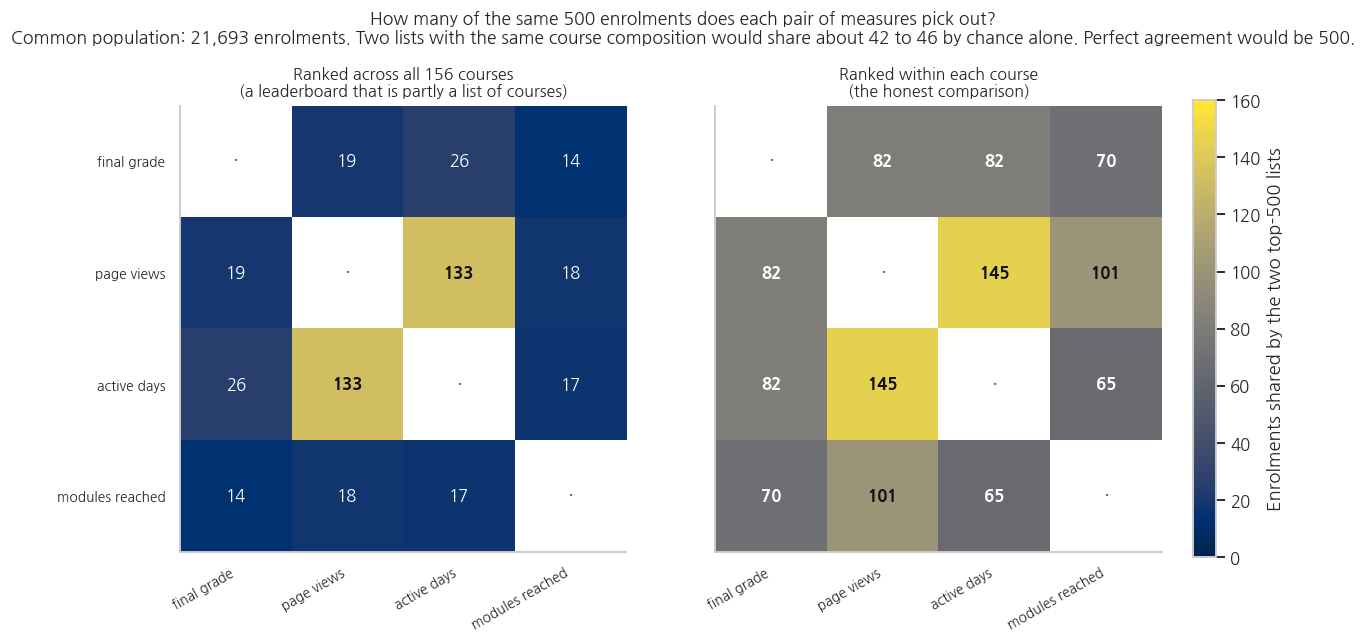

In [16]:
def draw_overlap(ax, mat, cols, labels, title):
    z = mat.loc[cols, cols].values.astype(float)
    shown = np.where(np.eye(len(cols), dtype=bool), np.nan, z)
    im = ax.imshow(shown, cmap='cividis', vmin=0, vmax=160)
    ax.set_xticks(range(len(cols)))
    ax.set_yticks(range(len(cols)))
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    for i in range(len(cols)):
        for j in range(len(cols)):
            if i == j:
                ax.text(j, i, '·', ha='center', va='center', color='#666666', fontsize=14)
            else:
                v = z[i, j]
                ax.text(j, i, '{:.0f}'.format(v), ha='center', va='center', fontsize=11,
                        color='white' if v < 95 else '#111111',
                        fontweight='bold' if v > 60 else 'normal')
    ax.set_title(title, fontsize=10.5)
    ax.grid(False)
    return im


short = [CATALOG.loc[m, 'short'] for m in FOUR]
fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.4))
im = draw_overlap(axes[0], med_raw, FOUR, short,
                  'Ranked across all {} courses\n(a leaderboard that is partly a list of courses)'
                  .format(core['course_id_DI'].nunique()))
draw_overlap(axes[1], med_cp, FOUR_CP, short,
             'Ranked within each course\n(the honest comparison)')
axes[1].set_yticklabels([])
cb = fig.colorbar(im, ax=axes, fraction=0.026, pad=0.03)
cb.set_label('Enrolments shared by the two top-500 lists')
fig.suptitle('How many of the same 500 enrolments does each pair of measures pick out?\n'
             'Common population: {:,} enrolments. Two lists with the same course composition '
             'would share about {:.0f} to {:.0f} by chance alone. Perfect agreement would be 500.'
             .format(len(core), np.nanmin(mch_cp.values), np.nanmax(mch_cp.values)),
             fontsize=11.5, y=1.03)
plt.show()

**Interpretation prompt.** Two panels, side by side, and neither of them shows the number you
guessed.

Read the right-hand panel first, because it is the defensible one, and read it against the
course-matched baseline rather than against the uniform 11. Once course composition is held fixed,
chance alone would put roughly 42 to 46 enrolments on both lists. So the pairs sit **above** chance,
by a factor of about one and a half, not by a factor of six. These measures are not measuring
unrelated things and they are not measuring the same thing either.

The closest any pair comes to agreement is 145 of 500, the two clicking measures agreeing with each
other, and that tells you mostly that they are one measure wearing two hats. Every pair involving the
grade sits at 82 or below, which is to say that at least four in five of the people on one list are
absent from the other. Notice how much work the baseline did: on the uniform number, 65 of 500 looks
like six times chance and therefore like strong agreement. Against the right baseline it is barely
above what course composition produces on its own.

Now the design question, which is the one that matters today. A dashboard does not show you the
middle. It shows you a top or a bottom, and it is exactly at the ends that these measures stop
agreeing with one another.

Discuss, with the persona cards in front of you:

1. Each of the four personas would walk out of this room with a different list of people to
   celebrate, and each list is defensible. Which one gets built in real life, and why that one?
2. The left panel is what you would have got if you had never checked the nesting. Say in one
   sentence what you would have concluded, and what it would have cost the people on the lists.
3. Nobody in this file was told which measure would be used. Does that change your answer to
   question 1?

### One more check, because the obvious objection is a good one

Someone will say: surely these measures just correlate, and the top-500 business is a trick of
looking at a narrow slice. Half right. Let us look.

Two correlation coefficients, because one would be misleading here. `nevents` runs from 1 to
530,411 and is violently right-skewed, so a Pearson correlation on the raw counts is dominated by a
handful of enormous values. Spearman uses the ranks instead, which is the honest summary for data
shaped like this.

In [17]:
sp = core[FOUR].corr(method='spearman')
pe = core[FOUR].corr(method='pearson')
print('Spearman (rank) correlations, common population, n = {:,}'.format(len(core)))
print(sp.round(3).to_string())
print()
print('Pearson (raw value) correlations, for contrast:')
print(pe.round(3).to_string())
print()
print('Look at grade against page views: Spearman {:.2f}, Pearson {:.2f}.'.format(
    sp.loc['grade', 'nevents'], pe.loc['grade', 'nevents']))
print('The gap is the skew. The largest page-view count here is {:,.0f}, against a median of {:,.0f}.'
      .format(core['nevents'].max(), core['nevents'].median()))
print()
print('So the objection is half right and the half it gets wrong is the important half:')
print('these measures agree moderately in the broad middle and hardly at all at the top.')
print('A rank correlation of {:.2f} sounds like agreement. It coexists with two top-500 lists'.format(
    sp.loc['grade', 'nevents']))
print('that share {:.0f} of 500 once you hold the course constant. Both are true at once, and'.format(
    med_cp.loc['grade_in_course', 'nevents_in_course']))
print('a dashboard lives at the end of the distribution where the agreement has run out.')

Spearman (rank) correlations, common population, n = 21,693
           grade  nevents  ndays_act  ncontent
grade      1.000    0.514      0.557     0.373
nevents    0.514    1.000      0.552     0.477
ndays_act  0.557    0.552      1.000     0.223
ncontent   0.373    0.477      0.223     1.000

Pearson (raw value) correlations, for contrast:
           grade  nevents  ndays_act  ncontent
grade      1.000    0.175      0.514     0.344
nevents    0.175    1.000      0.322     0.134
ndays_act  0.514    0.322      1.000     0.186
ncontent   0.344    0.134      0.186     1.000

Look at grade against page views: Spearman 0.51, Pearson 0.17.
The gap is the skew. The largest page-view count here is 530,411, against a median of 330.

So the objection is half right and the half it gets wrong is the important half:
these measures agree moderately in the broad middle and hardly at all at the top.
A rank correlation of 0.51 sounds like agreement. It coexists with two top-500 lists
that share 82 of 

**Interpretation prompt.** "The measures correlate, so it does not matter much which one I pick" is
one of the most common sentences in a learning analytics design meeting, and this section is the
counterexample. Moderate correlation across a whole population is perfectly compatible with almost
complete disagreement about who is at the top.

Write the two-sentence version you would say to a colleague who has just said that sentence to you.
The first sentence agrees with them. The second one is the one that matters.

## 6. 🔁 The swap: read your own sketch through someone else's eyes

This is the core move of the studio. You built something for one person. Now sit in a different
chair and read it back.

The next cell does the mechanical part: it takes your metric set and reports, for each of the other
three personas, what they could actually do with each metric and which of their stated fears it
touches. The mechanical part is only a prompt. The real critique is the sentence you say afterwards.

In [18]:
def critique(metrics, designed_for, viewer):
    p, v = PERSONAS[designed_for], PERSONAS[viewer]
    words = {0: 'CANNOT ACT on this', 1: 'can act, but only after a conversation',
             2: 'CAN ACT directly'}
    print('-' * 86)
    print('{}  {} ({}) reads a view built for {} ({})'.format(
        v['emoji'], v['name'], viewer, p['name'], designed_for))
    print('   They arrive asking: "{}"   (grain they need: {})'.format(v['question'], v['grain']))
    print('   Access reality: {}'.format(v['access_reality']))
    print()
    dead, scary = 0, []
    for m in metrics:
        rowc = CATALOG.loc[m]
        score = int(rowc['act_' + viewer])
        flagged = viewer in str(rowc['fears']).split(',')
        dead += (score == 0)
        if flagged:
            scary.append(rowc['label'])
        print('   {:<40} {}{}'.format(rowc['label'], words[score],
                                      '   <-- touches a stated fear' if flagged else ''))
        print('   {:<40} often mistaken for: {}'.format('', rowc['mistaken_for']))
    print()
    print('   Verdict: {} of {} metrics are inert for this person.'.format(dead, len(metrics)))
    if scary:
        print('   Touches their fears: ' + '; '.join(scary))
    if v['grain'] != p['grain']:
        print("   Grain mismatch: this view thinks in '{}', they need '{}'.".format(
            p['grain'], v['grain']))


for other in [k for k in PERSONA_ORDER if k != MY_PERSONA]:
    critique(MY_METRICS, MY_PERSONA, other)
print('-' * 86)

--------------------------------------------------------------------------------------
🎓  Malik Ferrer (learner) reads a view built for Dana Okonkwo (teacher)
   They arrive asking: "Did I get what I came for, and is anything here even about that?"   (grain they need: himself)
   Access reality: Sees a progress bar if the course has one. Sees none of the rest, and was never told this file would exist.

   Final grade recorded by the course       can act, but only after a conversation   <-- touches a stated fear
                                            often mistaken for: how much this person learned
   Reached a grade of 0.70 or more          can act, but only after a conversation   <-- touches a stated fear
                                            often mistaken for: completion, and then success
   Distinct days with any recorded activity can act, but only after a conversation   <-- touches a stated fear
                                            often mistaken for: commitment


Actionability: 0 = cannot act, 1 = only after a conversation, 2 = can act directly
                                          metric  teacher  learner  platform  funder touches the fear of
              Final grade recorded by the course        2        1         1       2     teacher,learner
                 Reached a grade of 0.70 or more        2        1         2       2     teacher,learner
               Recorded page views in the course        1        0         2       1             learner
              Recorded page views per active day        1        1         1       0             learner
        Distinct days with any recorded activity        1        1         2       2             learner
           Percent of the course modules reached        2        2         1       1              nobody
Platform flag: reached at least half the modules        1        0         2       1             learner

Total actionable weight per stakeholder (max 14):
teacher     10
learner    

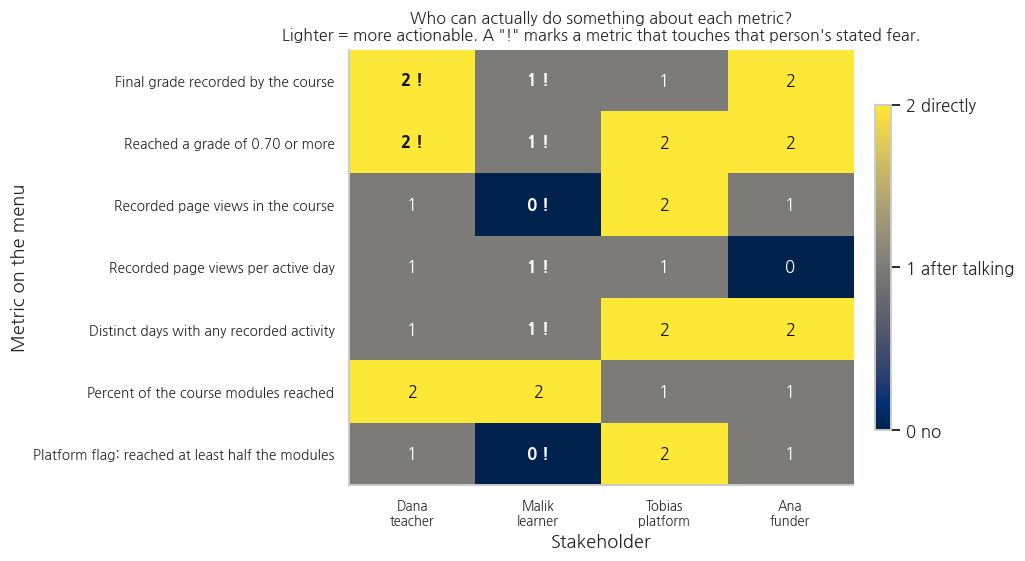

In [19]:
# The whole menu crossed with the whole room, as a table and as a picture.
act = CATALOG[['act_' + k for k in PERSONA_ORDER]].copy()
act.columns = PERSONA_ORDER
tbl = act.copy()
tbl.insert(0, 'metric', CATALOG['label'])
tbl['touches the fear of'] = CATALOG['fears'].replace('', 'nobody')
print('Actionability: 0 = cannot act, 1 = only after a conversation, 2 = can act directly')
print(tbl.to_string(index=False))
print()
print('Total actionable weight per stakeholder (max {}):'.format(2 * len(METRIC_KEYS)))
print(act.sum().to_string())

fig, ax = plt.subplots(figsize=(9.4, 5.2))
z = act.values.astype(float)
im = ax.imshow(z, cmap='cividis', vmin=0, vmax=2, aspect='auto')
ax.set_xticks(range(len(PERSONA_ORDER)))
ax.set_xticklabels(['{}\n{}'.format(PERSONAS[k]['name'].split()[0], k)
                    for k in PERSONA_ORDER], fontsize=8.5)
ax.set_yticks(range(len(METRIC_KEYS)))
ax.set_yticklabels([CATALOG.loc[m, 'label'] for m in METRIC_KEYS], fontsize=9)
for i, m in enumerate(METRIC_KEYS):
    for j, k in enumerate(PERSONA_ORDER):
        v = int(act.loc[m, k])
        mark = ' !' if k in str(CATALOG.loc[m, 'fears']).split(',') else ''
        ax.text(j, i, '{}{}'.format(v, mark), ha='center', va='center', fontsize=11,
                color='white' if v < 1.5 else '#111111', fontweight='bold' if mark else 'normal')
ax.set_xlabel('Stakeholder')
ax.set_ylabel('Metric on the menu')
ax.set_title('Who can actually do something about each metric?\n'
             'Lighter = more actionable. A "!" marks a metric that touches that '
             "person's stated fear.", fontsize=10.5)
ax.grid(False)
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04, ticks=[0, 1, 2])
cb.ax.set_yticklabels(['0 no', '1 after talking', '2 directly'])
plt.tight_layout()
plt.show()

**Interpretation prompt.** Read down the learner's column and then down the platform's. The person
every row of this file is about can act directly on one metric out of seven, and the company that
owns the file can act directly on four. Bang and Vossoughi (2016) would ask what relation that
pattern reproduces. Who ends up being the object of the measurement, and who ends up holding it?

Then look for the bright cells with a `!` beside them. Those are metrics somebody can act on
*and* has reason to dread. Those are the cells that need a co-design conversation rather than a
default setting.

### The file answers back

Here is what makes this dataset worth a whole session. In almost every learning analytics file, the
learner persona is a role-play. You have to imagine what they would say, and your imagination is
doing the arguing.

Not here. At registration Canvas Network asked people **what kind of participant they expected to
be**, and 35,110 enrolments answered. So when a group builds a completion dashboard and then swaps
into the learner's chair, the rebuttal is inside the data.

Two questions, in order.

1. If you put a completion bar on a screen, how many people does it mark as a "failure"? The word
   is the dashboard's, not ours, and the point of the exercise is to see how many people it fits.
2. How many of them told you in advance that they were not trying to complete?

In [20]:
BAR = 0.70

graded = pc['grade'].notna()
n_pass = int((pc['grade'] >= BAR).sum())
print('Question 1: who does a completion bar call a failure?')
print()
print('   Enrolments with a grade recorded at all : {:,}'.format(int(graded.sum())))
print('   Of those, {:,} reached {:.0%} or more   : {:.1f} percent'.format(
    n_pass, BAR, 100 * n_pass / graded.sum()))
print('   As a share of all {:,} rows in the file  : {:.1f} percent'.format(
    len(pc), 100 * n_pass / len(pc)))
print()
print('   A dashboard drawing its denominator from registrations would report a')
print('   {:.1f} percent completion rate and colour {:.1f} percent of the file red.'.format(
    100 * n_pass / len(pc), 100 - 100 * n_pass / len(pc)))
print('   Which denominator gets used is a design decision, and it moves the headline')
print('   number by a factor of four.')
print()

not_doing = survey['plan'].isin(['Passive participant', 'Drop-in', 'Observer'])
print('Question 2: what did they say they were going to do?')
print()
print('   Of the {:,} enrolments that answered ({:,} distinct people),'.format(
    len(survey), survey['userid_DI'].nunique()))
print('   {:,} ({:.1f} percent, {:,} distinct people) chose an answer that says'.format(
    int(not_doing.sum()), 100 * not_doing.mean(),
    survey.loc[not_doing, 'userid_DI'].nunique()))
print('   in so many words that they did not plan to do the assignments:')
print()
for lbl, n in survey.loc[not_doing, 'plan'].value_counts().items():
    print('      {:<22} {:>6,}'.format(lbl, n))
print()
print('   The remaining {:,} said they intended to take the course as a student and'.format(
    int((~not_doing).sum())))
print('   do the assignments.')

Question 1: who does a completion bar call a failure?

   Enrolments with a grade recorded at all : 82,002
   Of those, 17,515 reached 70% or more   : 21.4 percent
   As a share of all 325,199 rows in the file  : 5.4 percent

   A dashboard drawing its denominator from registrations would report a
   5.4 percent completion rate and colour 94.6 percent of the file red.
   Which denominator gets used is a design decision, and it moves the headline
   number by a factor of four.

Question 2: what did they say they were going to do?

   Of the 35,110 enrolments that answered (30,336 distinct people),
   18,941 (53.9 percent, 16,978 distinct people) chose an answer that says
   in so many words that they did not plan to do the assignments:

      Passive participant    13,582
      Drop-in                 2,820
      Observer                2,539

   The remaining 16,169 said they intended to take the course as a student and
   do the assignments.


In [21]:
# Grades by declared plan, with an interval that respects the nesting.
# Rows sit inside courses, and courses differ wildly in how they grade, so the
# resampling unit is the course, not the row. This is a cluster bootstrap.
def cluster_boot_median(frame, value_col, group_col, plan_col, plans, B=400, seed=31):
    r = np.random.default_rng(seed)
    courses = frame[group_col].unique()
    banks = {}
    for pl in plans:
        sub = frame[frame[plan_col] == pl]
        banks[pl] = {c: g[value_col].dropna().to_numpy()
                     for c, g in sub.groupby(group_col)}
    out = {pl: [] for pl in plans}
    for _ in range(B):
        pick = r.choice(courses, size=len(courses), replace=True)
        for pl in plans:
            bank = banks[pl]
            parts = [bank[c] for c in pick if c in bank]
            if parts:
                out[pl].append(np.median(np.concatenate(parts)))
    return {pl: np.percentile(v, [2.5, 97.5]) for pl, v in out.items() if v}


ci = cluster_boot_median(survey, 'grade', 'course_id_DI', 'plan', PLAN_ORDER)

print('Final grade by what the person said they intended to do, before the course started')
print('(median, with a 95 percent interval from resampling {} courses, not rows)'.format(
    survey['course_id_DI'].nunique()))
print()
rows = []
for pl in PLAN_ORDER:
    g = survey.loc[survey['plan'] == pl, 'grade'].dropna()
    lo, hi = ci[pl]
    rows.append(dict(plan=pl, enrolments=int((survey['plan'] == pl).sum()),
                     with_a_grade=len(g), median_grade=round(g.median(), 3),
                     interval='[{:.3f}, {:.3f}]'.format(lo, hi),
                     reached_070='{:,} of {:,} = {:.1f}%'.format(
                         int((g >= BAR).sum()), len(g), 100 * (g >= BAR).mean())))
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
print()
print('Read the intervals before the ordering. The four medians fall in the order you would')
print('expect, and the interval on each plan overlaps the interval on the plan next to it, so')
print('this file separates the ends of that list and not the neighbours. Then read the last')
print('column with the first one. {:.1f} percent of the people who told you they were only'.format(
    100 * (survey.loc[survey['plan'] == 'Observer', 'grade'].dropna() >= BAR).mean()))
print('going to watch cleared a 70 percent grade anyway. Whatever these answers are, they')
print('are not a clean sorting of people into finishers and non-finishers, and any design')
print('that treats them that way will be wrong about thousands of people.')

Final grade by what the person said they intended to do, before the course started
(median, with a 95 percent interval from resampling 145 courses, not rows)

               plan  enrolments  with_a_grade  median_grade       interval             reached_070
 Active participant       16169         13355         0.175 [0.103, 0.247] 3,822 of 13,355 = 28.6%
Passive participant       13582         11156         0.083 [0.032, 0.132] 2,289 of 11,156 = 20.5%
            Drop-in        2820          2273         0.022 [0.000, 0.070]    355 of 2,273 = 15.6%
           Observer        2539          1926         0.007 [0.000, 0.047]    257 of 1,926 = 13.3%

Read the intervals before the ordering. The four medians fall in the order you would
expect, and the interval on each plan overlaps the interval on the plan next to it, so
this file separates the ends of that list and not the neighbours. Then read the last
column with the first one. 13.3 percent of the people who told you they were only
going 

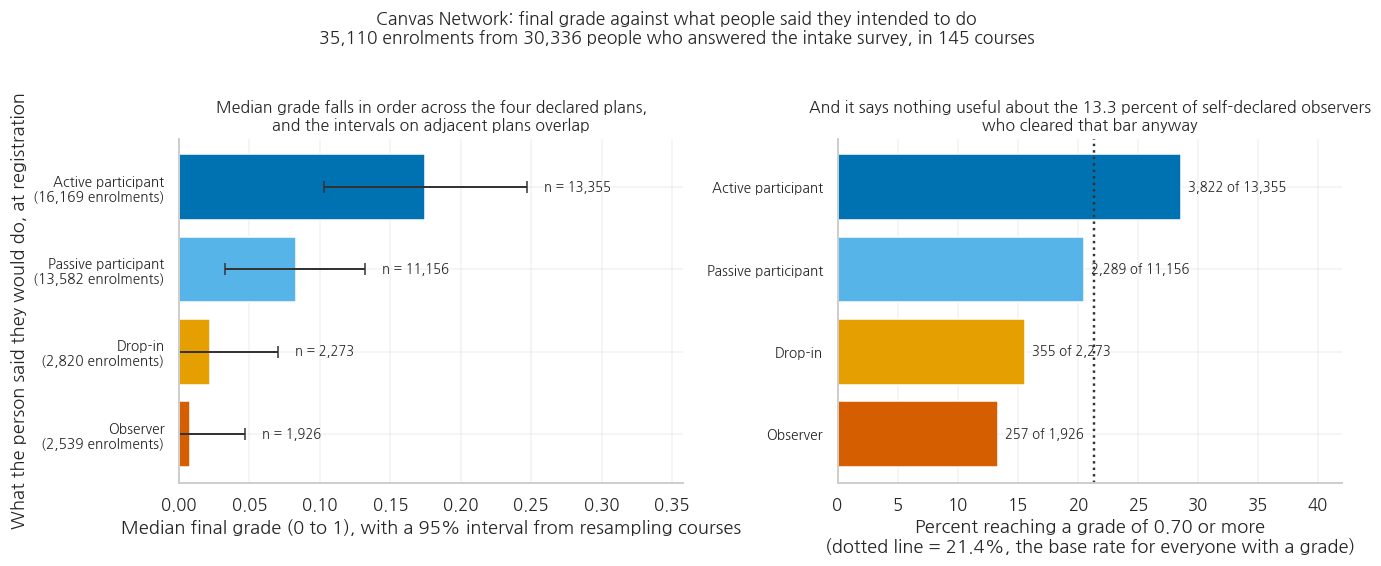

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.9))

# Left: median grade by declared plan, with cluster bootstrap intervals
ax = axes[0]
meds = [survey.loc[survey['plan'] == pl, 'grade'].dropna().median() for pl in PLAN_ORDER]
los = [ci[pl][0] for pl in PLAN_ORDER]
his = [ci[pl][1] for pl in PLAN_ORDER]
err = np.array([np.array(meds) - np.array(los), np.array(his) - np.array(meds)])
cols = [BLUE, SKY, ORANGE, VERM]
y = np.arange(len(PLAN_ORDER))
ax.barh(y, meds, xerr=err, color=cols, edgecolor='white', capsize=4,
        error_kw=dict(ecolor='#333333', elinewidth=1.3))
for i, pl in enumerate(PLAN_ORDER):
    n = int(survey.loc[survey['plan'] == pl, 'grade'].notna().sum())
    ax.text(his[i] + 0.012, i, 'n = {:,}'.format(n), va='center', fontsize=8.5)
ax.set_yticks(y)
ax.set_yticklabels(['{}\n({:,} enrolments)'.format(pl, int((survey['plan'] == pl).sum()))
                    for pl in PLAN_ORDER], fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, max(his) * 1.45)
ax.set_xlabel('Median final grade (0 to 1), with a 95% interval from resampling courses')
ax.set_ylabel('What the person said they would do, at registration')
ax.set_title('Median grade falls in order across the four declared plans,\n'
             'and the intervals on adjacent plans overlap', fontsize=10.5)

# Right: share reaching the 70 percent bar, counts on the bars
ax = axes[1]
share = [100 * (survey.loc[survey['plan'] == pl, 'grade'].dropna() >= BAR).mean()
         for pl in PLAN_ORDER]
ax.barh(y, share, color=cols, edgecolor='white')
for i, pl in enumerate(PLAN_ORDER):
    g = survey.loc[survey['plan'] == pl, 'grade'].dropna()
    ax.text(share[i] + 0.6, i, '{:,} of {:,}'.format(int((g >= BAR).sum()), len(g)),
            va='center', fontsize=8.5)
base = 100 * (pc['grade'].dropna() >= BAR).mean()
ax.axvline(base, color='#333333', linestyle=':', linewidth=1.6)
ax.set_yticks(y)
ax.set_yticklabels(PLAN_ORDER, fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, 42)
ax.set_xlabel('Percent reaching a grade of 0.70 or more\n'
              '(dotted line = {:.1f}%, the base rate for everyone with a grade)'.format(base))
ax.set_ylabel('')
obs = survey.loc[survey['plan'] == 'Observer', 'grade'].dropna()
ax.set_title('And it says nothing useful about the {:.1f} percent of self-declared observers\n'
             'who cleared that bar anyway'.format(100 * (obs >= BAR).mean()), fontsize=10.5)

fig.suptitle('Canvas Network: final grade against what people said they intended to do\n'
             '{:,} enrolments from {:,} people who answered the intake survey, in {} courses'
             .format(len(survey), survey['userid_DI'].nunique(),
                     survey['course_id_DI'].nunique()), fontsize=11.5, y=1.04)
plt.tight_layout()
plt.show()

In [23]:
# And what did they say they came for?
reasons = pc['primary_reason'].dropna()
reasons = reasons[reasons != 'Missing']
top = reasons.value_counts()
print('Why people said they registered, {:,} enrolments answering:'.format(len(reasons)))
print()
for lbl, n in top.items():
    print('   {:>6,}  ({:>4.1f}%)  {}'.format(n, 100 * n / len(reasons), lbl))
print()
print('The single most common answer, given by {:,} of {:,} ({:.1f} percent), is'.format(
    top.iloc[0], len(reasons), 100 * top.iloc[0] / len(reasons)))
print('"{}".'.format(top.index[0]))
print()
print('Now look back at the menu in section 3 and find the metric that measures that.')
print('There is not one. There is no column in this file that records whether a person')
print('enjoyed learning about a topic that interested them. Look back at OULAD in weeks 2,')
print('3, 4 and 8, and at the essay corpus in week 5, and there is none there either.')
print()
print('That is the finding to carry into your Rough Draft. The measures on the menu are not')
print('there because they matter most. They are there because they were the ones a web')
print('server writes down for free.')

Why people said they registered, 36,495 enrolments answering:

   20,494  (56.2%)  I enjoy learning about topics that interest me
    4,382  (12.0%)  I hope to gain skills for a new career
    2,958  ( 8.1%)  I like the format (online)
    2,319  ( 6.4%)  I am curious about MOOCs
    2,209  ( 6.1%)  I hope to gain skills for a promotion at work
    1,626  ( 4.5%)  I want to try Canvas Network
    1,294  ( 3.5%)  I enjoy being part of a community of learners
      780  ( 2.1%)  I am preparing to go back to school
      288  ( 0.8%)  I am preparing for college for the first time
      145  ( 0.4%)  I hope to gain skills to use at work

The single most common answer, given by 20,494 of 36,495 (56.2 percent), is
"I enjoy learning about topics that interest me".

Now look back at the menu in section 3 and find the metric that measures that.
There is not one. There is no column in this file that records whether a person
enjoyed learning about a topic that interested them. Look back at OULAD 

**Interpretation prompt, and the boundary on it.** Everything in the last three cells is about
**respondents**. 35,110 enrolments answered the learner-type question, out of 325,199 rows. That is
10.8 percent. We have no idea whether the other 89.2 percent would have answered the same way, and
there are good reasons to think they would not: answering a survey at registration is itself a sign
of some engagement with the course.

So the correct sentence is not "most learners were not trying to complete". It is: **of the people
who answered, a majority said they were not planning to do the assignments, and a completion
dashboard would have counted every one of them as a failure.** That sentence is defensible. The
other one is not, and the difference between them is the whole of what this course teaches about
range restriction. It is the same lesson as Week 5's spans nested inside single essays and Week 9's
eight groups.

Three questions for the swap:

1. Your persona's dashboard is on the screen and Malik is looking over your shoulder. He answered
   the survey. Which sentence do you say to him first?
2. The survey is 11 years old and was answered by a tenth of the file. Would you still put it in
   the design meeting? What would you have to say alongside it?
3. What would you have had to ask people, at registration, for the dashboard you sketched to be
   about the thing they came for? Write the question. It is one sentence, and almost nobody in this
   field asks it.

## 7. 🕰️ Retroactive design audit: the semester we already built

Here is the uncomfortable part. We have spent ten weeks building analytics artifacts about real
people, on real published data, and this notebook makes eleven. We did it the way the field usually
does it: researchers deciding what to measure, with the measured parties absent from the room.

The next cell lists every artifact from weeks 1 through 11, names the dataset it used and the design
decision it quietly made, and asks you to score how much voice each persona should have had, from
0 to 3:

- `0` no legitimate stake
- `1` should have been informed
- `2` should have been consulted before it was built
- `3` should have held a veto

**The four personas travel across the weeks under different names.** In every one of these datasets
there was somebody who built the learning experience (the *teacher* column), somebody it was for
(the *learner* column), an institution or company whose system did the recording (the *platform*
column), and somebody who paid for or commissioned the work (the *funder* column). The names change,
the four positions do not.

The dictionary comes pre-filled with the instructor's first guess. **It is a first guess and you are
expected to argue with it.** Change numbers, re-run, and be ready to defend one cell you moved.

Two nuances worth catching.

Week 10 is a science game played by children, and week 6 is 78 children working with a robot. The
four persona labels carry very different weight when the learner is a child and a guardian is not
one of the four columns. That absence is a finding, and it is what stretch task 1 exists for.

And read the wording of the descriptions themselves. Where a week used one of the field's
deficit-coded terms, the description quotes it rather than repeats it, because **which words an
artifact chose is one of the design decisions being audited.** "Risk" and "hint spam" are somebody's
choice of vocabulary, and every one of them arrived without the person it describes in the room.

In [24]:
# Each description names the decision the artifact made, in the active voice, because the
# point of the audit is that somebody chose. Deficit-coded terms are quoted, not adopted.
ARTIFACTS = {
    'W1  first real table':
        ('UCI student performance, 395 secondary students in Portugal',
         'Chose which background columns to stand beside a final grade, and decided in public '
         'that a column of zeros was a recording failure rather than a group of students.'),
    'W2  mapping the landscape':
        ('OULAD, module BBB, two presentations',
         'Chose recorded clicks as the thing worth counting, and reported how little of an '
         'outcome they account for.'),
    'W3  bias audit':
        ('OULAD, module BBB, and UCI student performance',
         'Named the target after a registry outcome rather than "risk", then audited whom the '
         'model flags across deprivation deciles and disability status, twice, in two countries.'),
    'W4  teacher dashboard':
        ('OULAD, module BBB',
         'Chose which panels a teacher sees first, and therefore what she never sees.'),
    'W5  text analytics':
        ('PERSUADE 2.0, four prompts',
         "Turned students' written arguments into discourse-move tags and effectiveness ratings "
         'that somebody else had scored.'),
    'W6  multimodal participation':
        ('JUSThink, children working with a robot at EPFL',
         'Defined participation out of speech seconds and interface actions, because those are '
         'the channels the room happened to record.'),
    'W7  help-seeking traces':
        ('EdNet KT3, users of a commercial test-prep tutor in Korea',
         'Picked thirty minutes for what a study session is and ten seconds for what counts as '
         'reading an explanation, and quoted the field\'s "gaming the system" and "hint spam" '
         'as objects of study rather than applying either to anybody.'),
    'W8  networks and time':
        ('An edX MOOC forum, and OULAD, module BBB',
         'Chose which reply counts as a tie and who counts as a connector, built a withdrawal '
         'curve from real unregistration dates, and tested whether submitting close to a '
         'deadline goes with lower scores.'),
    'W9  collaboration':
        ('A Spanish computer-networks chat log, and the JUSThink records',
         'Scored groups on how evenly the recorded talk was shared, retired a response-time '
         'measure the platform clock could not support, and carried the measure into a second '
         'setting that has an outcome where the first has none.'),
    'W10 game analytics':
        ('Open Game Data, Field Day Lab, two games',
         'Read what children did at a hard moment in a game as a predictor of what they did '
         'next, and read six words on a mood menu as evidence about how they felt.'),
    'W11 today, this notebook':
        ('Canvas Network person-course, 325,199 enrolments',
         'Ranked enrolments four different ways and put 500 names on each list, without asking '
         'one of them which measure they would have chosen.'),
}

# ✏️ EDIT THE NUMBERS: 0 no stake, 1 inform, 2 consult, 3 veto.
#    Order is [teacher, learner, platform, funder].
AUDIT = {
    'W1  first real table':        [3, 3, 1, 0],
    'W2  mapping the landscape':   [2, 3, 2, 0],
    'W3  bias audit':              [3, 3, 2, 1],
    'W4  teacher dashboard':       [3, 2, 1, 1],
    'W5  text analytics':          [2, 3, 1, 0],
    'W6  multimodal participation': [3, 3, 1, 1],
    'W7  help-seeking traces':     [2, 3, 2, 0],
    'W8  networks and time':       [2, 3, 2, 1],
    'W9  collaboration':           [3, 3, 0, 0],
    'W10 game analytics':          [2, 3, 1, 2],
    'W11 today, this notebook':    [3, 3, 3, 1],
}

audit_df = pd.DataFrame(AUDIT, index=PERSONA_ORDER).T
audit_df.index.name = 'artifact'

print('What each artifact used, and what it decided:')
print()
for k, (dataset, decision) in ARTIFACTS.items():
    print('  {}'.format(k))
    print('     data: {}'.format(dataset))
    print('     decision: {}'.format(decision))
print()
print('Voice scores (0 none, 1 inform, 2 consult, 3 veto):')
print(audit_df.to_string())
print()
print('Total voice per stakeholder across the semester (max {}):'.format(3 * len(AUDIT)))
print(audit_df.sum().to_string())
print()
print('Number of these artifacts built with that stakeholder in the room: 0, for all four.')

What each artifact used, and what it decided:

  W1  first real table
     data: UCI student performance, 395 secondary students in Portugal
     decision: Chose which background columns to stand beside a final grade, and decided in public that a column of zeros was a recording failure rather than a group of students.
  W2  mapping the landscape
     data: OULAD, module BBB, two presentations
     decision: Chose recorded clicks as the thing worth counting, and reported how little of an outcome they account for.
  W3  bias audit
     data: OULAD, module BBB, and UCI student performance
     decision: Named the target after a registry outcome rather than "risk", then audited whom the model flags across deprivation deciles and disability status, twice, in two countries.
  W4  teacher dashboard
     data: OULAD, module BBB
     decision: Chose which panels a teacher sees first, and therefore what she never sees.
  W5  text analytics
     data: PERSUADE 2.0, four prompts
     decision: Tur

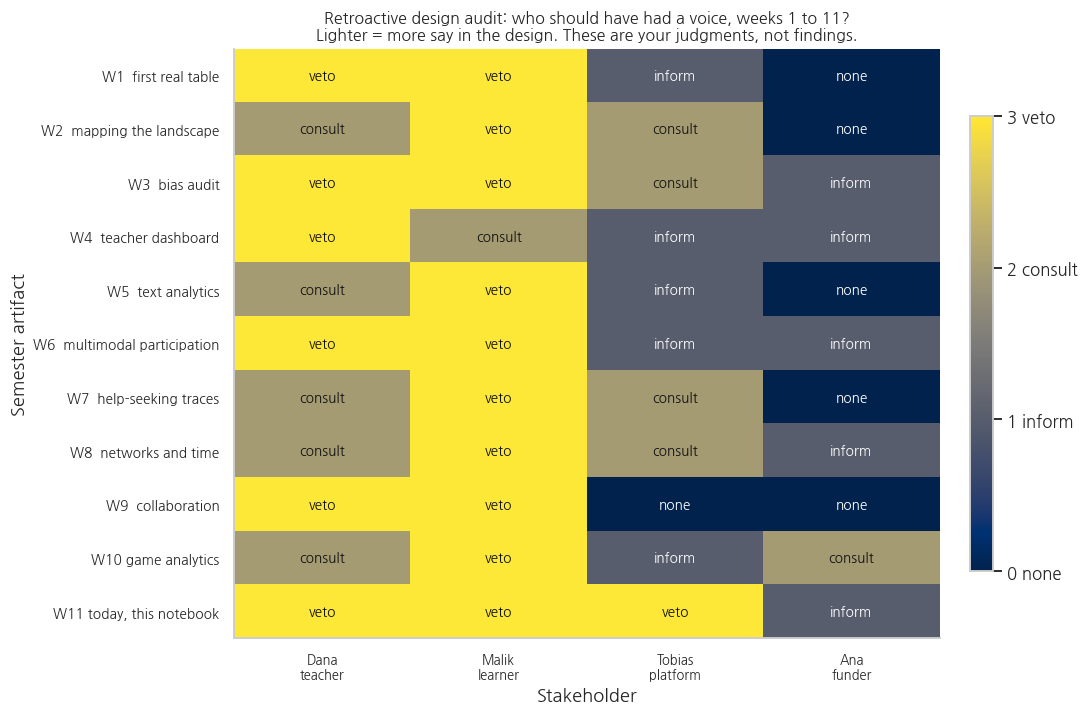

In [25]:
level_words = {0: 'none', 1: 'inform', 2: 'consult', 3: 'veto'}
fig, ax = plt.subplots(figsize=(10.0, 6.6))
z = audit_df.values.astype(float)
im = ax.imshow(z, cmap='cividis', vmin=0, vmax=3, aspect='auto')
ax.set_xticks(range(len(PERSONA_ORDER)))
ax.set_xticklabels(['{}\n{}'.format(PERSONAS[k]['name'].split()[0], k)
                    for k in PERSONA_ORDER], fontsize=8.5)
ax.set_yticks(range(len(audit_df)))
ax.set_yticklabels(list(audit_df.index), fontsize=9)
for i in range(z.shape[0]):
    for j in range(z.shape[1]):
        v = int(z[i, j])
        ax.text(j, i, level_words[v], ha='center', va='center', fontsize=9,
                color='white' if v < 2 else '#111111')
ax.set_xlabel('Stakeholder')
ax.set_ylabel('Semester artifact')
ax.set_title('Retroactive design audit: who should have had a voice, weeks 1 to 11?\n'
             'Lighter = more say in the design. These are your judgments, not findings.',
             fontsize=10.5)
ax.grid(False)
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04, ticks=[0, 1, 2, 3])
cb.ax.set_yticklabels(['0 none', '1 inform', '2 consult', '3 veto'])
plt.tight_layout()
plt.show()

**Interpretation prompt.** Read the column totals printed above the heatmap, not just the colours.
In the default scoring the learner column is almost full and every one of these artifacts was built
without a single learner in the room. That gap between "should have had a voice" and "had a voice"
is what Prieto-Alvarez and colleagues (2018) are writing about when they insist on co-designing
*with* learners rather than for them.

Two harder questions to carry into your Rough Draft.

1. Pick the one artifact where you moved a score, and say what would have **changed about the
   artifact itself** if that stakeholder had been consulted. Not what would have felt better. What
   would be different on the screen.
2. The last row is today. This notebook put 500 names on four lists and none of those people were
   asked. The data is eleven years old and the people in it are unreachable, which is a real
   constraint and also the most comfortable excuse in the field. What is the smallest thing this
   notebook could have done differently and still been this notebook?

## 8. ✏️ Your turn (stretch, optional)

Only if you finish early. Nothing later depends on these.

1. **Add a persona this platform has no column for.** Copy an entry in `PERSONAS`, change the key,
   and write a fifth stakeholder: a guardian of a child in the week 6 or week 10 data, a disability
   services coordinator, a translator, a research ethics board. Then add an `act_<yourkey>` column
   to `CATALOG` and redraw the actionability figure.
2. **Build the refusal list.** Write the metrics you would refuse to display to *any* of the four
   personas, and the sentence you would put in the interface where they would have gone.
3. **Two measures, one person.** The cell below plots recorded page views against final grade for
   the survey respondents in the common population, coloured by what they said they intended to do.
   The two off-diagonal corners are lists of specific people. Decide what a responsible tool does
   with each corner.

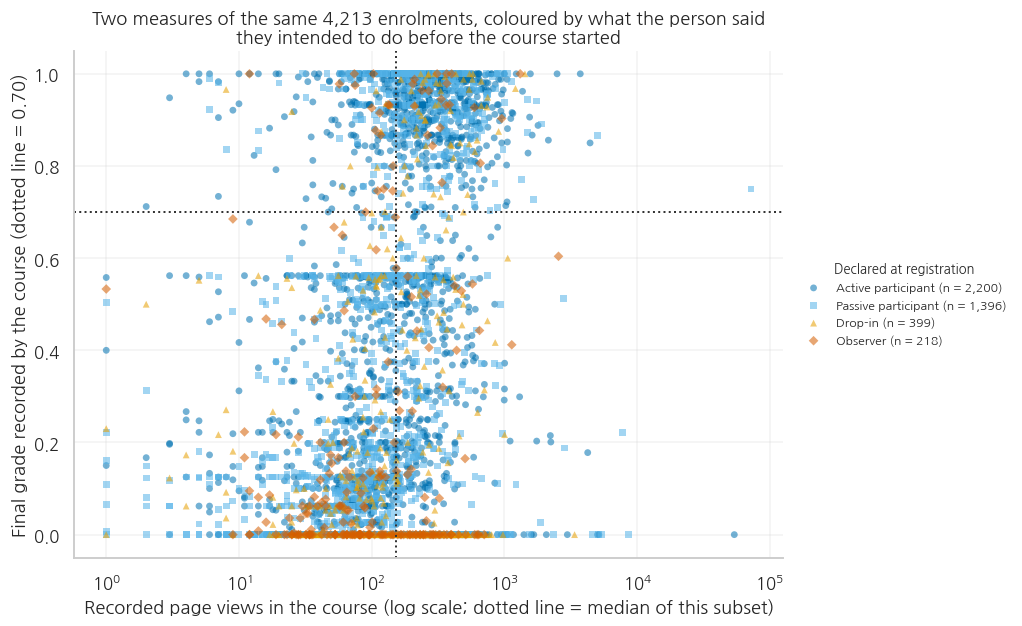

Upper-left  (few page views, grade at or above 0.70): 275 enrolments
Lower-right (many page views, grade below 0.70)     : 1,217 enrolments

Of the 1,217 in the lower-right corner, 649 (53 percent) had said they intended
to do the assignments. A dashboard built on grade puts them on a worry list.
A dashboard built on page views puts them on a leaderboard. Both are this file.


In [26]:
# A worked start for stretch 3. Change nothing and it runs; edit it and it is yours.
sub = core[core['learner_type'].notna() & (core['learner_type'] != 'Missing')].copy()
sub['plan'] = sub['learner_type'].replace(MERGE)

fig, ax = plt.subplots(figsize=(9.4, 5.8))
styles = [('Active participant', BLUE, 'o'), ('Passive participant', SKY, 's'),
          ('Drop-in', ORANGE, '^'), ('Observer', VERM, 'D')]
for pl, colr, mk in styles:
    s = sub[sub['plan'] == pl]
    ax.scatter(s['nevents'], s['grade'], c=colr, marker=mk, s=20, alpha=0.55,
               edgecolor='none', label='{} (n = {:,})'.format(pl, len(s)))
ax.set_xscale('log')
vline = sub['nevents'].median()
hline = 0.70
ax.axvline(vline, color='#333333', linestyle=':', linewidth=1.3)
ax.axhline(hline, color='#333333', linestyle=':', linewidth=1.3)
ax.set_xlabel('Recorded page views in the course (log scale; dotted line = median of this subset)')
ax.set_ylabel('Final grade recorded by the course (dotted line = 0.70)')
ax.set_title('Two measures of the same {:,} enrolments, coloured by what the person said\n'
             'they intended to do before the course started'.format(len(sub)))
ax.legend(title='Declared at registration', fontsize=8, title_fontsize=8.5, loc='center left',
          bbox_to_anchor=(1.01, 0.5), frameon=False)
plt.tight_layout()
plt.show()

busy_low = sub[(sub['nevents'] > vline) & (sub['grade'] < hline)]
quiet_high = sub[(sub['nevents'] <= vline) & (sub['grade'] >= hline)]
print('Upper-left  (few page views, grade at or above 0.70): {:,} enrolments'.format(len(quiet_high)))
print('Lower-right (many page views, grade below 0.70)     : {:,} enrolments'.format(len(busy_low)))
print()
print('Of the {:,} in the lower-right corner, {:,} ({:.0f} percent) had said they intended'.format(
    len(busy_low), int((busy_low['plan'] == 'Active participant').sum()),
    100 * (busy_low['plan'] == 'Active participant').mean()))
print('to do the assignments. A dashboard built on grade puts them on a worry list.')
print('A dashboard built on page views puts them on a leaderboard. Both are this file.')

**Interpretation prompt.** Neither corner is an anomaly to be explained away. Each is a list of
specific people, and the two dashboards would do opposite things to them.

Before you design anything for the Rough Draft, decide what your system does when two of its own
metrics disagree about the same person. "Show both" is an answer only if you can say what the reader
is supposed to do with the disagreement.

## 💬 Reflection

Write a few sentences for each. These are the questions the discussion block will open with, and
they are also usable material for your Rough Draft.

**1. Design starts before the data (Carvalho, Martinez-Maldonado, Tsai, Markauskaite, and De Laat,
2022).** Their argument is that designing for learning in an AI world means starting from the
activity, its purposes, and the setting, rather than from the traces a system happens to produce.
Every measure on today's menu is something a web server writes down for free. The most common answer
people gave for why they registered has no column at all. Name the activity you would have had to
design first for a measure of that answer to be worth reading.

**2. Participation is a relation, not a property (Bang and Vossoughi, 2016).** Participatory design
research, in their framing, is about studying and changing relations, not about collecting
stakeholder preferences and then proceeding as planned. Look at the actionability figure. The person
the file is about can act directly on one metric of seven; the company that owns the file can act on
four. Which relation does your sketch reproduce, and what would have to change for the sketch to be
different?

**3. Co-designing with learners (Prieto-Alvarez, Martinez-Maldonado, and Anderson, 2018).** They
work with learners as designers rather than as data sources. In your retroactive audit the learner
column carries the most weight and had the least presence. Pick one artifact from weeks 1 to 11 and
describe, concretely, what a 45-minute co-design session with five of the people in that dataset
would have had to produce for the artifact to change.

**4. Turn it on yourself.** Your course research project proposes a system, an analysis, or an
intervention. Who has decision rights over the thing you are proposing, and who is measured by it?
If those are different people, say in one sentence how your Rough Draft handles that. Then say which
measure you chose, and what a defensible second measure would have picked out instead.

## ✅ Submission checklist

**This notebook is not submitted.** Week 11 has no mini project. It is a studio, and the artifact you
leave with is the argument you can now make in your writing.

Still, do these two things before you close the tab:

- [ ] **Save your copy.** In Colab: `File > Save a copy in Drive`. Your persona choice, your metric
      set, and your audit numbers are the record of what you decided today.
- [ ] **Paste three things into your project notes**: your metric set with the one-sentence defense
      of why those and not others, the one audit cell you moved with your reason for moving it, and
      the sentence you would say to Malik with your dashboard on the screen.

**Due this week, submitted separately on Canvas (not from this notebook):**

- [ ] **Course Research Project Rough Draft**, per the Week 11 Rough Draft Guidelines. Word document,
      APA 7, building toward the 20-page final.
- [ ] **AI interaction log**, pasted into a Word file and attached to the Canvas "AI Reflection"
      submission, not into the text box. Per the course AI policy, any AI use in drafting must be
      documented: the tool, the prompts, and what you did with the output.
- [ ] **AI reflection**, typed into the text box on that same page: copy in and answer the four
      questions from the syllabus. Undisclosed AI use is an Honor Code violation, and disclosed use is
      completely fine.

If you used an AI tool while working through this notebook, that counts and belongs in the log too.

## Appendix: solutions to the "✏️ Your turn" cells

There is no single right answer in a co-design studio, so these are **worked examples**, not keys.
Compare your reasoning against them and note where you disagree. Disagreeing well is the skill.

### Section 4: a defensible metric set for each persona

| Persona | A defensible set | Why |
|---|---|---|
| Course team (Dana) | `ncontent`, `ndays_act`, `grade` | Modules reached tells her which parts of the course people got to, which is the question behind "which two modules do I cut". Grade is on the list because she wrote the assessment and it is hers to revise, not because it ranks anybody. |
| Learner (Malik) | `ncontent` alone | The only metric on the menu he can act on directly and the only one that is about the thing he said he came for. No comparison with anyone else, which removes the fear of being ranked and loses nothing he could have used. |
| Platform (Tobias) | `nevents`, `ndays_act` | Both are genuinely his to act on and both are honest about being measures of platform usage rather than of learning. The defensible version of his dashboard is one that says so in the title. |
| Funder (Ana) | `ndays_act`, and a second measure chosen by the grantee | Active days is the closest thing here to "did the money buy sustained use". Letting the grantee name the second measure is the cheapest piece of co-design available in this whole notebook, and it costs the foundation nothing. |

The set nobody should build: `passed_70` on its own, for anyone. It is the measure that reports a
5.4 percent success rate on a platform where a majority of survey respondents said they were not
attempting the assignments.

### Section 5: what the four steps were for

Step 1 gave a spectacular number and it was wrong, or rather it was a true statement about the file's
missingness dressed up as a statement about learners. Step 2 caught it. Step 3 asked the question on
a population where it could be answered. Step 4 caught the second confound, which was that a
leaderboard across 156 courses is substantially a list of courses.

The finding that survives all four steps is the modest one, and it is still enough to run a design
session on: **holding the course constant, four defensible measures of the same enrolments produce
four largely different top-500 lists, somewhat above what course composition alone would produce and
nowhere near agreement.** Note which baseline that sentence uses. Against a uniform baseline of 11 the
same overlaps look like five or six times chance; against the course-matched baseline of about 42 to 46
they look like one and a half times it. Both numbers are arithmetically correct and only one of them
answers the question, which is whether the measures agree about **people** rather than about courses.
If your Rough Draft proposes a measure, that is the sentence its limitations section owes the reader,
and the choice of baseline is the sentence before it.

### Section 7: the audit cell most people move

The common move is `W10 game analytics`, and the argument is that the learners are children, so a
guardian belongs in the room. But there is no guardian column, so the move people actually make is
to raise the `funder` or `platform` score as a proxy, which is the wrong repair. The right repair is
to add a fifth column, which is stretch task 1. That the persona set has to be re-opened when the
learner is a child is itself a design finding worth a paragraph.

The second most common move is the last row, this notebook, `platform` from 3 to 2 or 1, on the
grounds that Canvas Network already published the file under a licence that permits exactly this.
That is a real argument. Notice that it is an argument about a licence, and that a licence is a
thing a company grants, not a thing the people in the file were asked about.

### The stretch: a fifth persona worth adding

The guardian of a child in the week 6 or week 10 data. Their column is almost all `3`s in the rows
where the learner is a minor and almost all `0`s everywhere else, which makes them the one persona
whose relevance is a property of the dataset rather than of the role. Any table that has to be
re-opened when the age of the learner changes was never a table about roles. It was a table about
one particular kind of learner, and it took a child to show it.

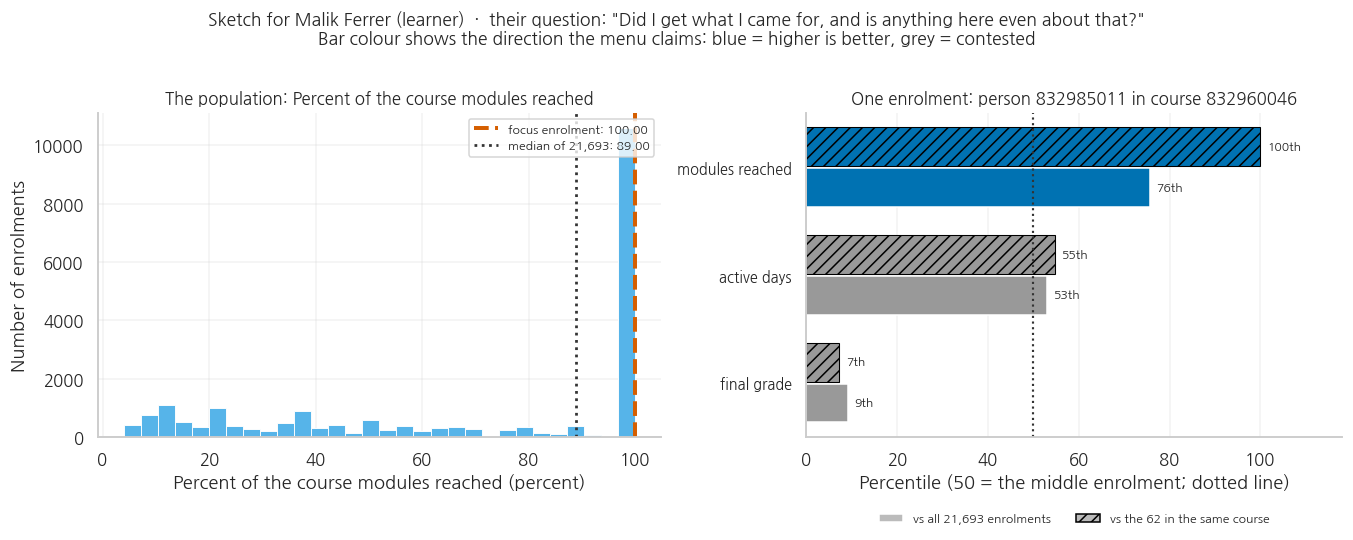

In [27]:
# Worked example for section 4: the same sketch for a different persona and metric set.
# Read the two side by side and say what changed and why.
sketch_view('learner', ['ncontent', 'ndays_act', 'grade'], FOCUS)
plt.show()

In [28]:
# Worked example for section 7: compare two audit scorings and show only where they disagree.
ALT_AUDIT = dict(AUDIT)
ALT_AUDIT['W10 game analytics'] = [2, 3, 1, 1]           # funder down: they did not commission the labelling
ALT_AUDIT['W11 today, this notebook'] = [3, 3, 1, 1]     # platform down: the licence already permits this
ALT_AUDIT['W5  text analytics'] = [2, 3, 2, 1]           # platform and funder up: a test contractor held the essays

alt_df = pd.DataFrame(ALT_AUDIT, index=PERSONA_ORDER).T
diff = alt_df - audit_df
changed = diff.loc[(diff != 0).any(axis=1)]
if len(changed):
    print('Cells where the alternative scoring disagrees with yours (positive = more voice):')
    print(changed.to_string())
    print()
    print('Column totals, yours against the alternative:')
    print(pd.DataFrame({'yours': audit_df.sum(), 'alternative': alt_df.sum()}).to_string())
    print()
    print('Defend or reject each one in a sentence. A score you cannot defend is a score you')
    print('borrowed, and the totals were never the interesting part.')
else:
    print('Your scoring already matches this alternative. Find someone in the room who disagrees.')

Cells where the alternative scoring disagrees with yours (positive = more voice):
                          teacher  learner  platform  funder
W5  text analytics              0        0         1       1
W10 game analytics              0        0         0      -1
W11 today, this notebook        0        0        -2       0

Column totals, yours against the alternative:
          yours  alternative
teacher      28           28
learner      32           32
platform     16           15
funder        7            7

Defend or reject each one in a sentence. A score you cannot defend is a score you
borrowed, and the totals were never the interesting part.
